In [1]:
getwd()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [2]:
.libPaths()

[1] "/fast/home/y/ykazci/R/x86_64-unknown-linux-gnu-library/4.3"               
[2] "/gnu/store/asn7yfxccx9hqi4afrnw685xw6c6382z-profile/site-library"         
[3] "/gnu/store/29x2k7i71g9xq09xmbj1lk515cl7if63-r-minimal-4.4.2/lib/R/library"

In [3]:
here::here()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [4]:
# Retrieve the BPCells library path:

# The original BPCells guix profile contains less number of packages than the
# corresponding renv profile hydrated from the original guix profile.
# Therefore, I will use the renv library path.

bpcells_lib <- "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/renv_envs/BPCELLS/renv/library/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu"

In [5]:
.libPaths(new = bpcells_lib, include.site = FALSE)

In [6]:
.libPaths()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/renv_envs/BPCELLS/renv/library/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu"
[2] "/gnu/store/29x2k7i71g9xq09xmbj1lk515cl7if63-r-minimal-4.4.2/lib/R/library"

In [7]:
library(BPCells)

In [8]:
here::here()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [9]:
source(here::here('r_scripts', 'plot_TF_footprints_with_BPCells_package.r'))

In [10]:
library(magrittr)

In [11]:
plot_multiple_TFs_w_highlights %>% args()

function (tf_genes, peaks_gr, fragments, metadata, pwms_mat, 
    genes, colors_highlight, line_thickness = 1, set_theme, set_margin) 
NULL

===========================================

Load all the required input objects: 

===========================================

In [12]:
peaks_gr <-  readRDS(here::here('r_objects', 'peaks_granges_for_TF_footprinting_by_BPCells.RDS'))

In [13]:
subsetted_fragments <- open_fragments_dir(dir = here::here('bpcells_counts', 'subsetted_fragments'))

In [14]:
# read metadata to use cell types:

metadata <- readRDS(file = here::here('r_objects', 'metadata.RDS'))

In [15]:
my_human_pwms_v2 <-  readRDS(here::here('r_objects', 'my_human_pwms_v2.RDS'))

In [16]:
genome_annotation_dir <- "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/renv_envs/BPCELLS/pbmc-3k/references"

genes_info <- read_gencode_transcripts(
  genome_annotation_dir, 
  release="42", 
  transcript_choice="MANE_Select",
  annotation_set = "basic", 
  features="transcript" # Make sure to set this so we don't get exons as well
)
head(genes_info)

chr,source,feature,start,end,score,strand,frame,gene_id,gene_type,gene_name,transcript_id,MANE_Select
<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
chr1,HAVANA,transcript,65418,71585,.,+,.,ENSG00000186092.7,protein_coding,OR4F5,ENST00000641515.2,TRUE
chr1,HAVANA,transcript,450739,451678,.,-,.,ENSG00000284733.2,protein_coding,OR4F29,ENST00000426406.4,TRUE
chr1,HAVANA,transcript,685715,686654,.,-,.,ENSG00000284662.2,protein_coding,OR4F16,ENST00000332831.5,TRUE
chr1,HAVANA,transcript,923922,944574,.,+,.,ENSG00000187634.13,protein_coding,SAMD11,ENST00000616016.5,TRUE
chr1,HAVANA,transcript,944202,959256,.,-,.,ENSG00000188976.11,protein_coding,NOC2L,ENST00000327044.7,TRUE
chr1,HAVANA,transcript,960583,965719,.,+,.,ENSG00000187961.15,protein_coding,KLHL17,ENST00000338591.8,TRUE


In [17]:
highlight_EC_v2 <- ggplot2::scale_color_manual(values =  c("#F6222EFF", rep(x = "#D3D3D380", times = 8) ))

In [18]:
my_theme <- ggplot2::theme(
    axis.title.x = ggplot2::element_text(size = 14),  # X-axis title size
    axis.title.y = ggplot2::element_text(size = 14),  # Y-axis title size
    axis.text.x  = ggplot2::element_text(size = 14, angle = 45, hjust = 1),  # X-axis tick labels
    axis.text.y  = ggplot2::element_text(size = 14),  # Y-axis tick labels
    legend.text  = ggplot2::element_text(size = 15)   # Legend text size
)

my_margin <- ggplot2::theme(plot.margin = ggplot2::unit(c(1, 1, 1, 1), "cm"))  # Add margin to top, right, bottom, and left margins, respectively.

In [19]:
plot_multiple_TFs_w_highlights <- function(
                                               tf_genes, 
                                               peaks_gr, 
                                               fragments, 
                                               metadata, 
                                               pwms_mat,
                                               genes, # must be here.
                                               colors_highlight,
                                               line_thickness = 1,
                                               set_theme,
                                               set_margin) {


plot_list <- list()

    for (each_TF in tf_genes) {
    
    p1 <- analyze_multiple_tf_footprints(tf_names = each_TF, 
                               peaks_gr = peaks_gr, 
                               fragments = fragments, 
                               metadata = metadata, 
                               pwms_mat = pwms_mat, # changed here. It was wrongly set.
                               genes = genes, # must be here.
                               line_thickness = 1)

    p2 <- p1 & colors_highlight

    plot_list[[each_TF]] <- p1 + p2 & set_theme & set_margin
        
    }

    return(plot_list)
}

In [20]:
options(repr.plot.width = 30, repr.plot.height = 7)

Motifs selected: SOX17


Attaching package: 'BiocGenerics'


The following object is masked from 'package:BPCells':

    as.data.frame


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, saveRDS, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min



Attaching package: 'S4Vectors'


The following object is masked from 'package:utils':

    findMatches


The following objects are masked from 'package:base':

    I, expand.grid, unname



Attaching package: 'GenomicRanges'


The following object is masked from 'package:magrittr':

    subtract



Attaching packag

$SOX17


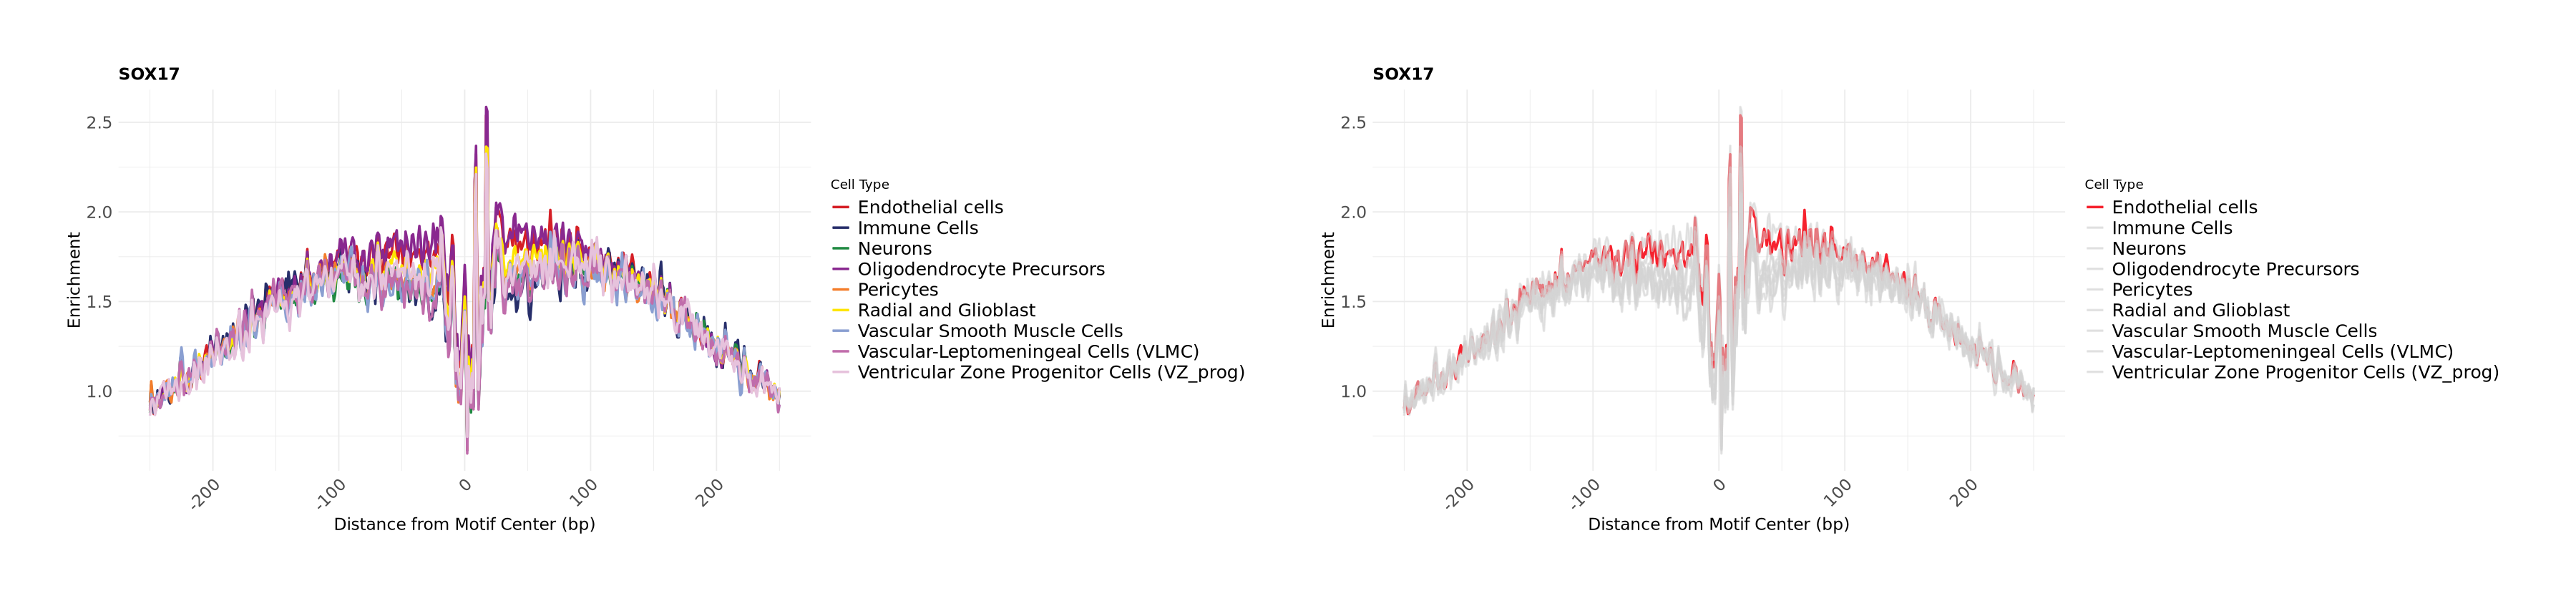

In [21]:
plot_multiple_TFs_w_highlights(tf_genes = 'SOX17', 
                               peaks_gr = peaks_gr, 
                               fragments = subsetted_fragments, 
                               metadata = metadata, 
                               pwms_mat = my_human_pwms_v2, 
                               genes =  genes_info, 
                               colors_highlight =  highlight_EC_v2, 
                               set_theme = my_theme, 
                               set_margin = my_margin)

In [22]:
# TFs found in both GRaNPA RF analysis and TFs' targets' logFC deviation analysis:

important_TFs <- c("FOXP1", "RFX3", "ZFPM2", "TEAD1", "DACH1", "YBX1", "ZNF521")

================================

I modified the TF footprint plotting functions to handle the un-matched input TFs gracefully.

========================================================

Summary of Fixes:

Handle missing TFs gracefully:\
Instead of stop(), return NULL and issue a warning().

Skip NULL results:
In plot_multiple_TFs_w_highlights, next is used to continue to the next TF if no match is found.

Now, if a TF has no match:\
A warning will be displayed instead of stopping execution.\
The function will move on to the next TF instead of failing.

In [26]:
# handle non-found TFs gracefully:

analyze_multiple_tf_footprints <- function (tf_names, peaks_gr, fragments, metadata, pwms_mat, genes, line_thickness = 1.5) {
    suppressPackageStartupMessages({
        library(stringr)
        library(motifmatchr)
        library(chromVARmotifs)
        library(ggplot2)
        library(patchwork)
    })
    if (!is.character(tf_names)) {
        stop("tf_names must be a character vector of transcription factor names.")
    }

    motif_matches <- unlist(lapply(tf_names, function(tf) {
        str_subset(names(pwms_mat), pattern = tf)
    }))

    if (length(motif_matches) == 0) {
        warning(paste("No motifs found for TF:", paste(tf_names, collapse=", "), "Skipping..."))
        return(NULL)  # Return NULL instead of stopping execution
    }

    selected_motifs <- setNames(motif_matches, tf_names)
    message("Motifs selected: ", paste(names(selected_motifs), collapse = ", "))

    suppressWarnings({
        motif_positions <- motifmatchr::matchMotifs(pwms_mat[selected_motifs], peaks_gr, genome = "hg38", out = "positions")
    })

    names(motif_positions) <- names(selected_motifs)
    
    footprinting_plots <- lapply(names(selected_motifs), function(motif) {
        plot_tf_footprint(fragments, motif_positions[[motif]], 
            cell_groups = metadata$main_cell_types, zero_based_coords = !is(genes, "GRanges"), 
            flank = 250, smooth = 2) + 
            ggplot2::labs(title = motif) + 
            ggplot2::theme_minimal() + 
            ggplot2::theme(plot.title = ggplot2::element_text(size = 14, face = "bold")) + 
            ggplot2::guides(color = ggplot2::guide_legend(title = "Cell Type")) + 
            ggplot2::geom_line(linewidth = line_thickness)
    })

    if (length(footprinting_plots) == 1) {
        return(footprinting_plots[[1]])
    } else {
        return(patchwork::wrap_plots(footprinting_plots, guides = "collect", ncol = 1))
    }
}

In [27]:
plot_multiple_TFs_w_highlights <- function (tf_genes, peaks_gr, fragments, metadata, pwms_mat, genes, colors_highlight, line_thickness = 1, set_theme, set_margin) {
    plot_list <- list()
    
    for (each_TF in tf_genes) {
        p1 <- analyze_multiple_tf_footprints(tf_names = each_TF, 
            peaks_gr = peaks_gr, fragments = fragments, metadata = metadata, 
            pwms_mat = pwms_mat, genes = genes, line_thickness = line_thickness)

        if (is.null(p1)) {
            next  # Skip to the next TF if no match was found
        }

        p2 <- p1 & colors_highlight
        plot_list[[each_TF]] <- p1 + p2 & set_theme & set_margin
    }
    
    return(plot_list)
}

In [28]:
cat('plot_multiple_TFs_w_highlights\n\n')

plot_multiple_TFs_w_highlights

cat('analyze_multiple_tf_footprints\n\n')

analyze_multiple_tf_footprints

plot_multiple_TFs_w_highlights



function (tf_genes, peaks_gr, fragments, metadata, pwms_mat, genes, colors_highlight, line_thickness = 1, set_theme, set_margin) {
    plot_list <- list()
    
    for (each_TF in tf_genes) {
        p1 <- analyze_multiple_tf_footprints(tf_names = each_TF, 
            peaks_gr = peaks_gr, fragments = fragments, metadata = metadata, 
            pwms_mat = pwms_mat, genes = genes, line_thickness = line_thickness)

        if (is.null(p1)) {
            next  # Skip to the next TF if no match was found
        }

        p2 <- p1 & colors_highlight
        plot_list[[each_TF]] <- p1 + p2 & set_theme & set_margin
    }
    
    return(plot_list)
}

analyze_multiple_tf_footprints



function (tf_names, peaks_gr, fragments, metadata, pwms_mat, genes, line_thickness = 1.5) {
    suppressPackageStartupMessages({
        library(stringr)
        library(motifmatchr)
        library(chromVARmotifs)
        library(ggplot2)
        library(patchwork)
    })
    if (!is.character(tf_names)) {
        stop("tf_names must be a character vector of transcription factor names.")
    }

    motif_matches <- unlist(lapply(tf_names, function(tf) {
        str_subset(names(pwms_mat), pattern = tf)
    }))

    if (length(motif_matches) == 0) {
        warning(paste("No motifs found for TF:", paste(tf_names, collapse=", "), "Skipping..."))
        return(NULL)  # Return NULL instead of stopping execution
    }

    selected_motifs <- setNames(motif_matches, tf_names)
    message("Motifs selected: ", paste(names(selected_motifs), collapse = ", "))

    suppressWarnings({
        motif_positions <- motifmatchr::matchMotifs(pwms_mat[selected_motifs], peaks_gr, genome = "hg38", out = "positions")
    })

    names(motif_positions) <- names(selected_motifs)
    
    footprinting_plots <- lapply(names(selected_motifs), function(motif) {
        plot_tf_footprint(fragments, motif_positions[[motif]], 
            cell_groups = metadata$main_cell_types, zero_based_coords = !is(genes, "GRanges"), 
            flank = 250, smooth = 2) + 
            ggplot2::labs(title = motif) + 
            ggplot2::theme_minimal() + 
            ggplot2::theme(plot.title = ggplot2::element_text(size = 14, face = "bold")) + 
            ggplot2::guides(color = ggplot2::guide_legend(title = "Cell Type")) + 
            ggplot2::geom_line(linewidth = line_thickness)
    })

    if (length(footprinting_plots) == 1) {
        return(footprinting_plots[[1]])
    } else {
        return(patchwork::wrap_plots(footprinting_plots, guides = "collect", ncol = 1))
    }
}

In [29]:
my_important_TFs_plots <- plot_multiple_TFs_w_highlights(tf_genes = important_TFs, # it takes multiple inputs.
                               peaks_gr = peaks_gr, 
                               fragments = subsetted_fragments, 
                               metadata = metadata, 
                               pwms_mat = my_human_pwms_v2, 
                               genes =  genes_info, 
                               colors_highlight =  highlight_EC_v2, 
                               set_theme = my_theme, 
                               set_margin = my_margin)

Motifs selected: FOXP1

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Motifs selected: RFX3

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message in analyze_multiple_tf_footprints(tf_names = each_TF, peaks_gr = peaks_gr, :
"No motifs found for TF: ZFPM2 Skipping..."
Motifs selected: TEAD1

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message in analyze_multiple_tf_footprints(tf_names = each_TF, peaks_gr = peaks_gr, :
"No motifs found for TF: DACH1 Skipping..."
Motifs selected: YBX1

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message in analyze_multiple_tf_footprints(tf_names = each_TF, peaks_gr = peaks_gr, :
"No motifs found for TF: ZNF521 Skipping..."


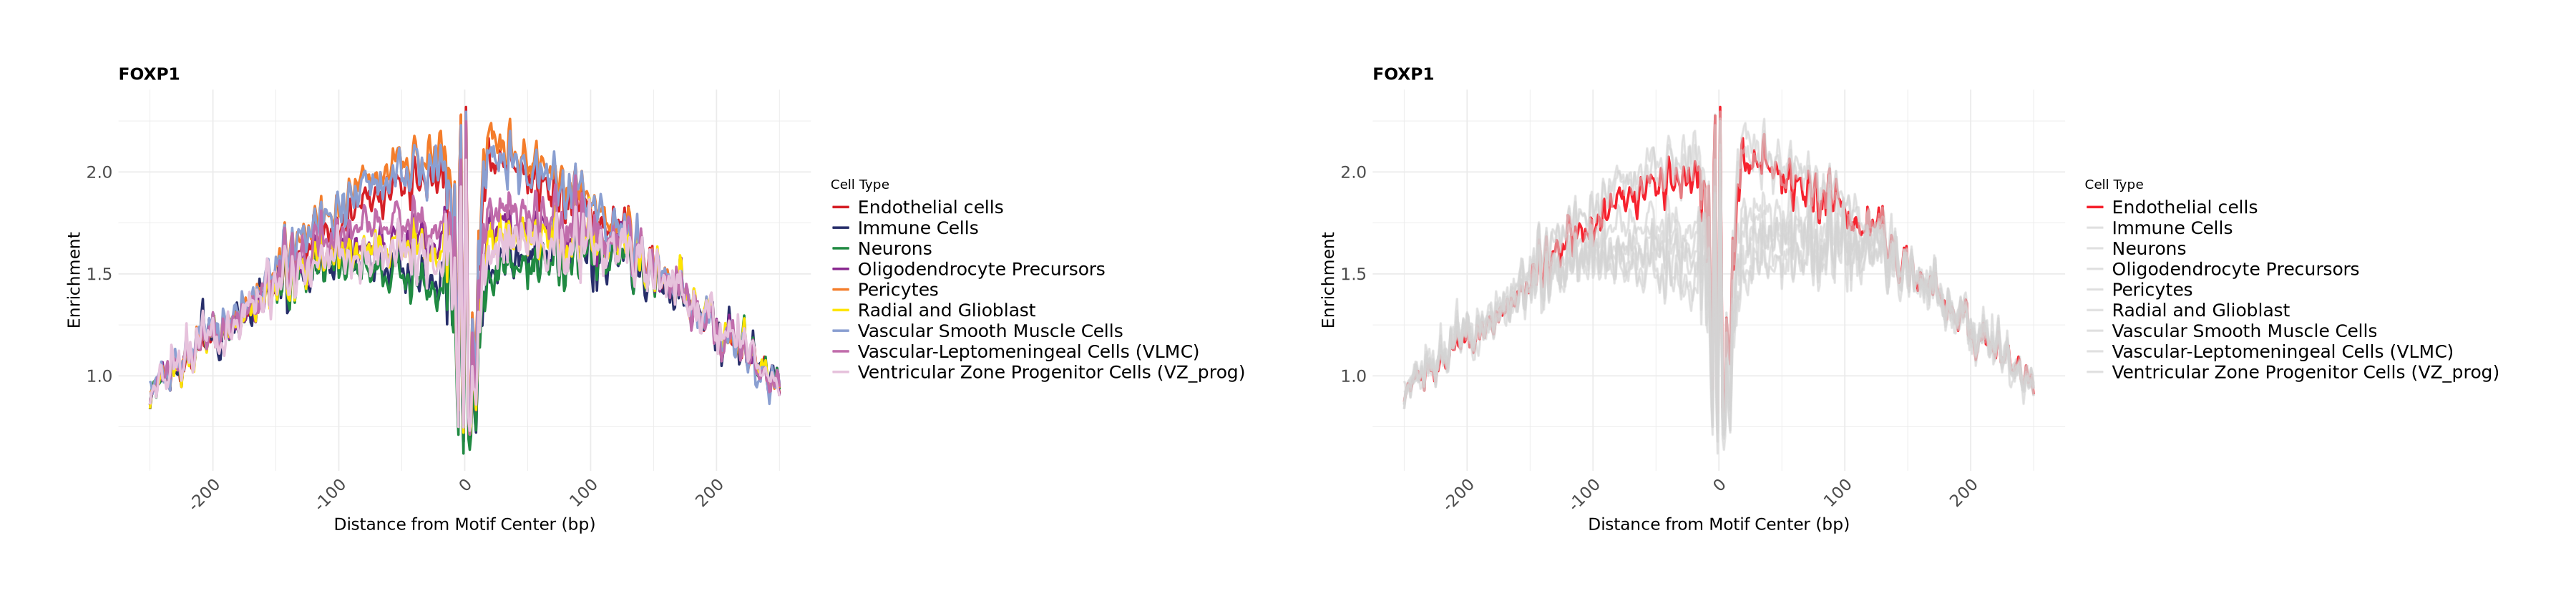

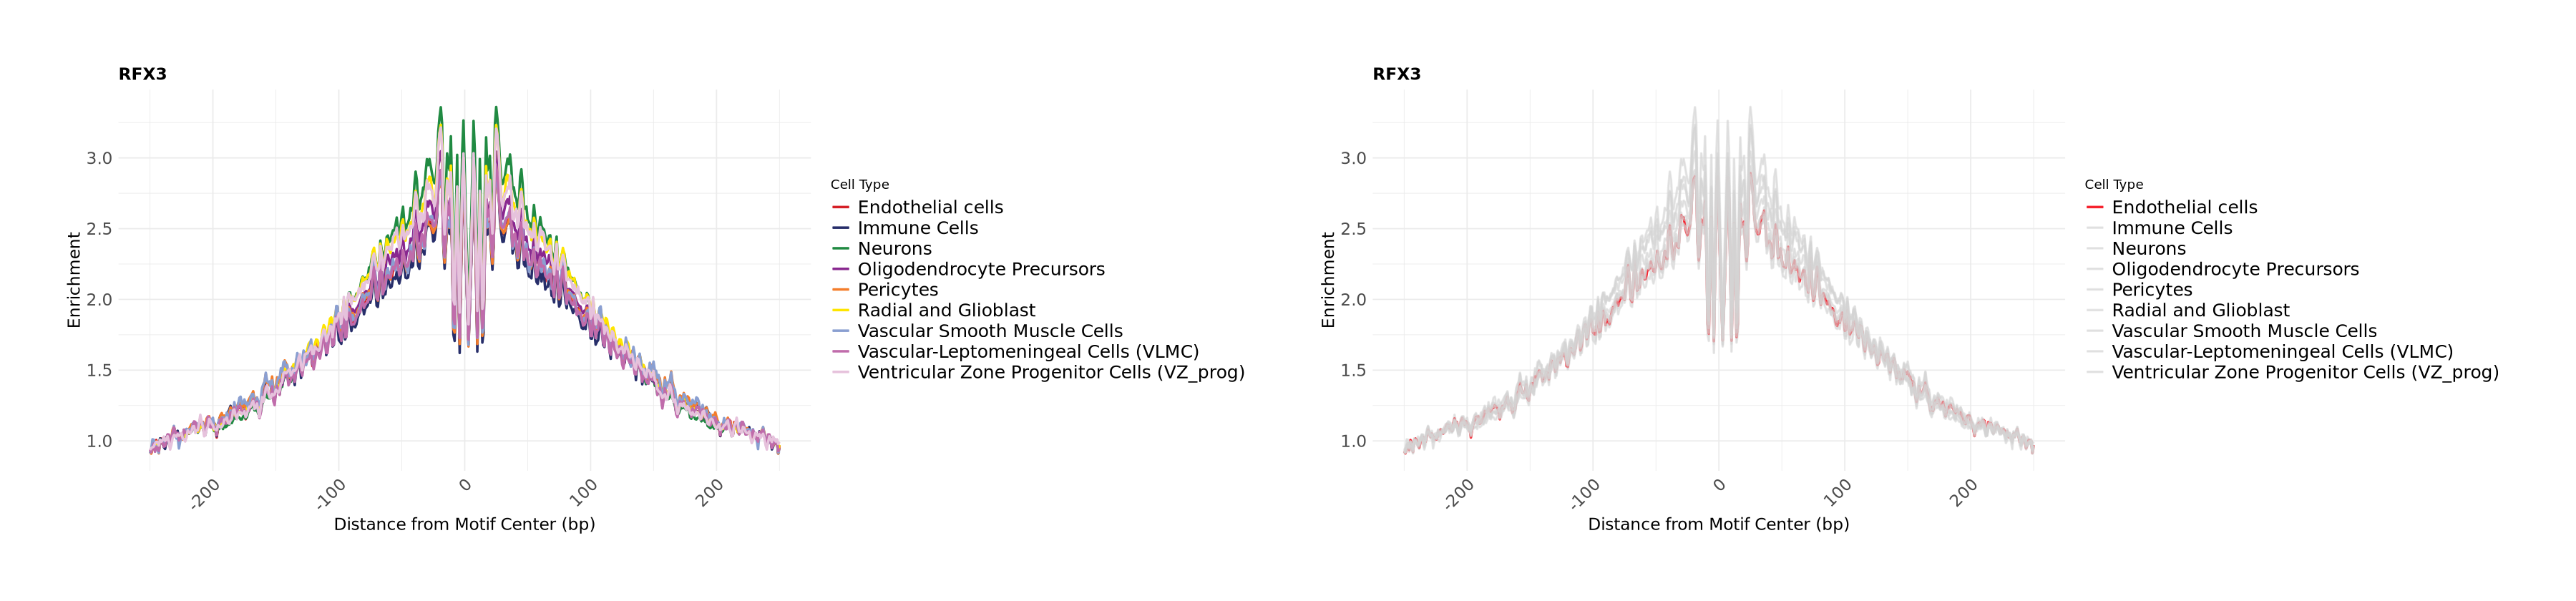

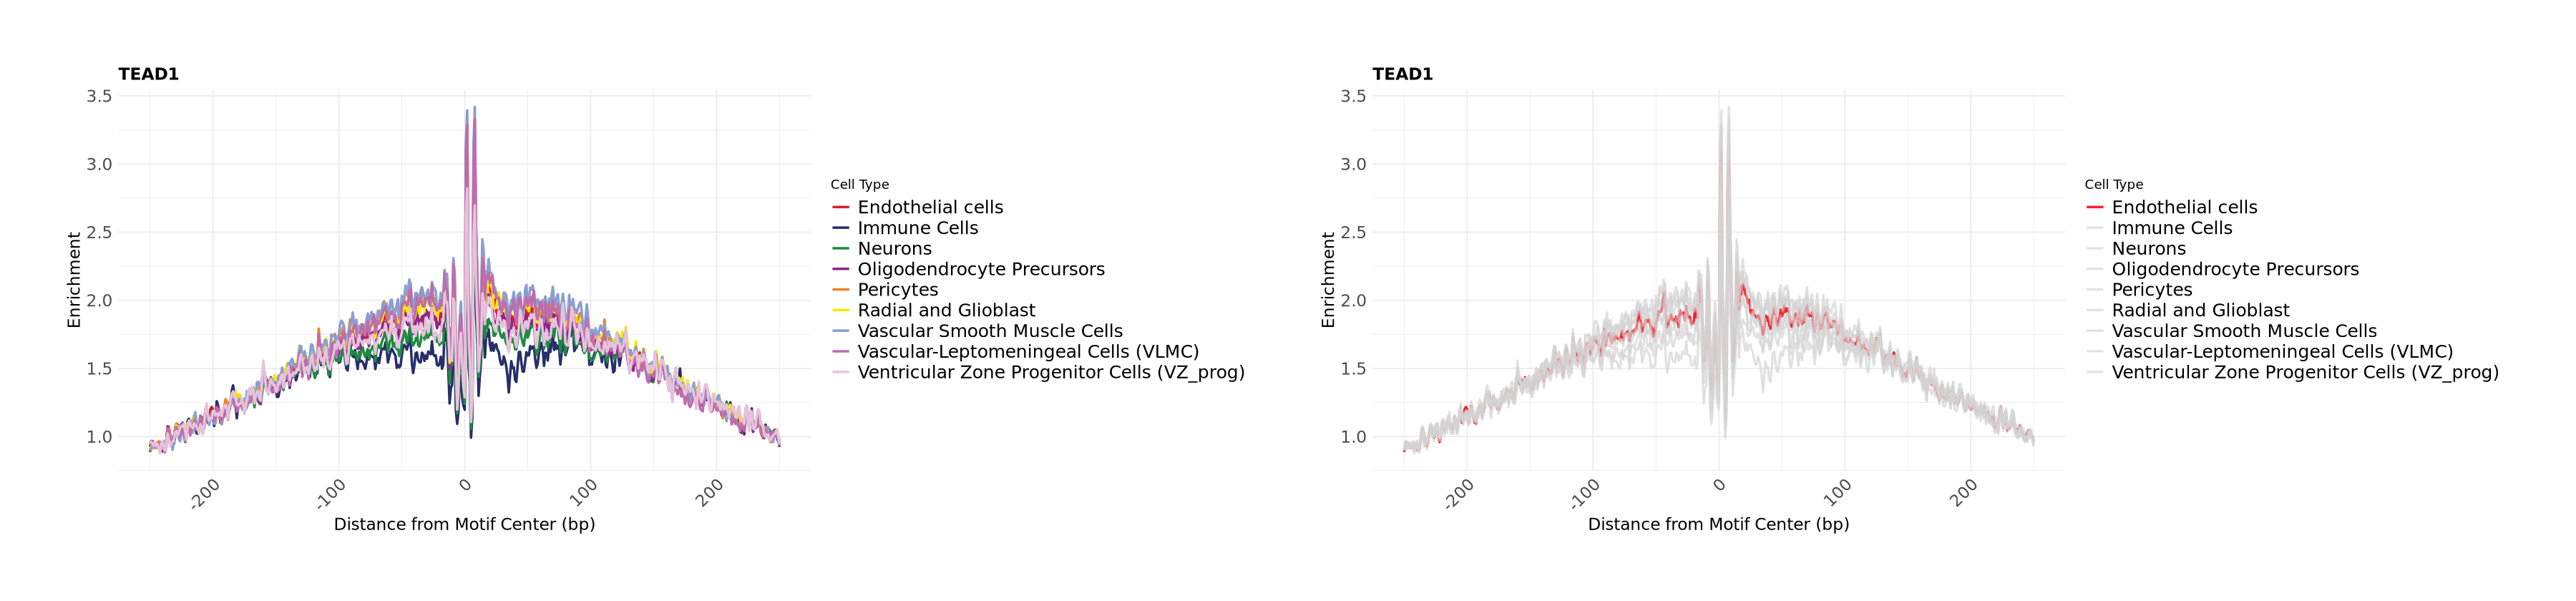

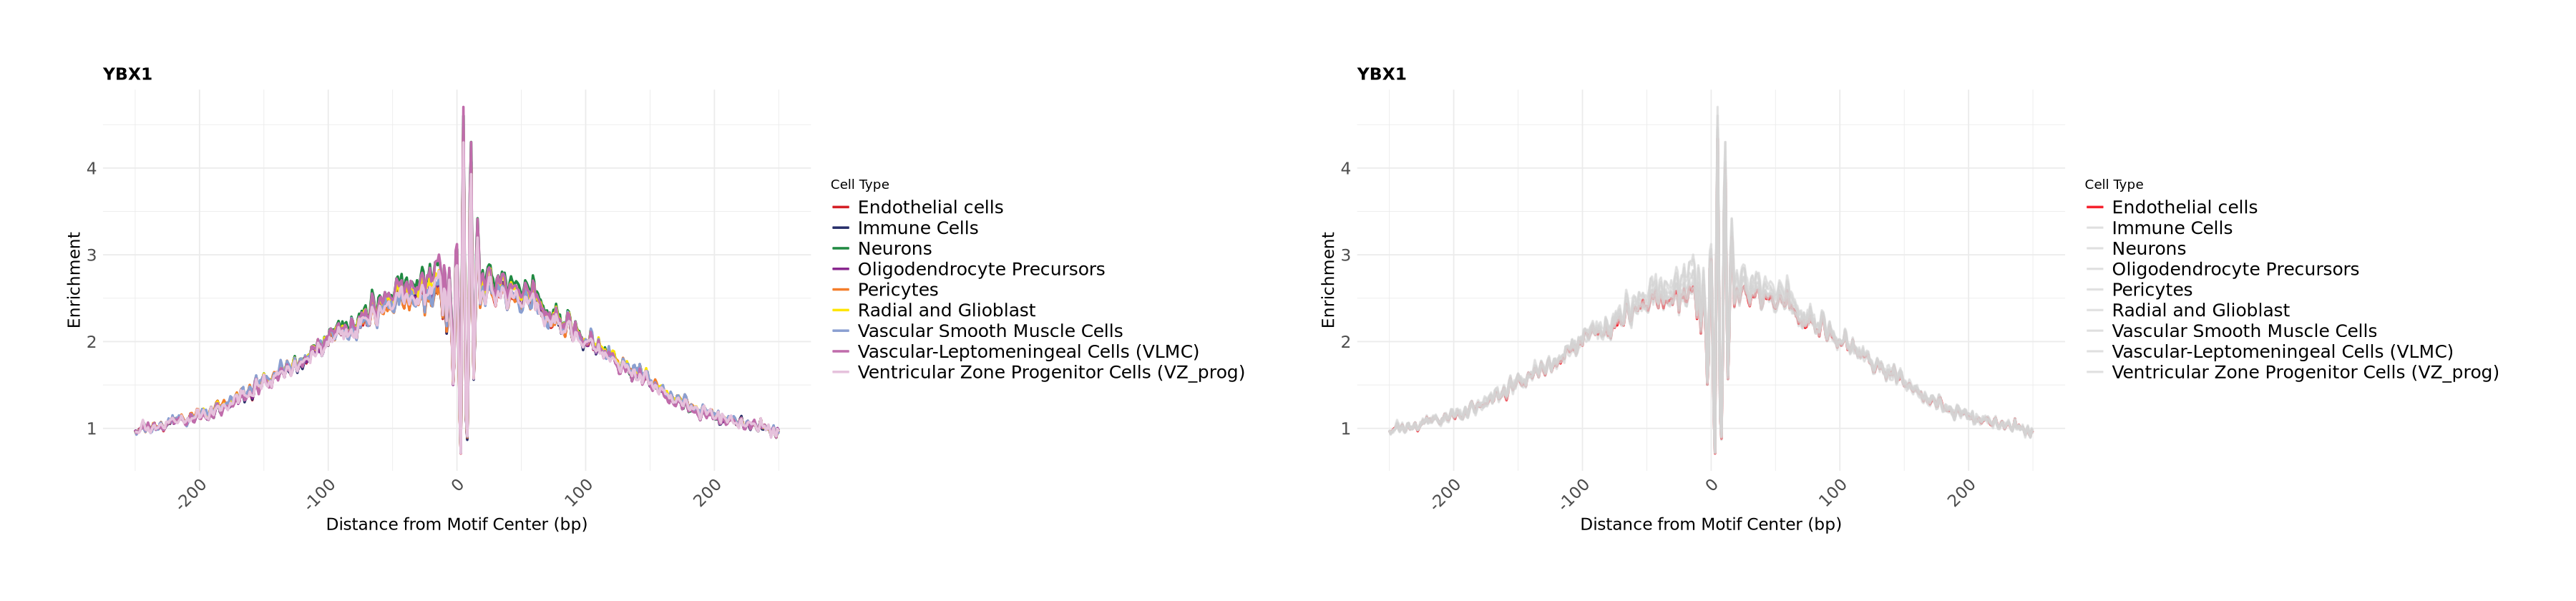

In [30]:
options(repr.plot.width = 30, repr.plot.height = 7)

for(each_plot in my_important_TFs_plots){

    print(each_plot)
    
    }

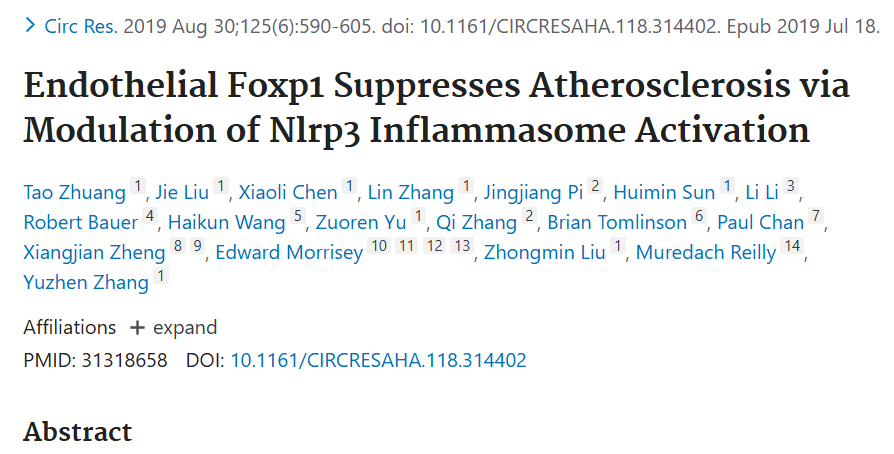

https://www.ahajournals.org/doi/10.1161/CIRCRESAHA.118.314402

==========================================================================

Test modified function with individual TF inputs, to verify it yields identical results.

Motifs selected: FOXP1

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


$FOXP1


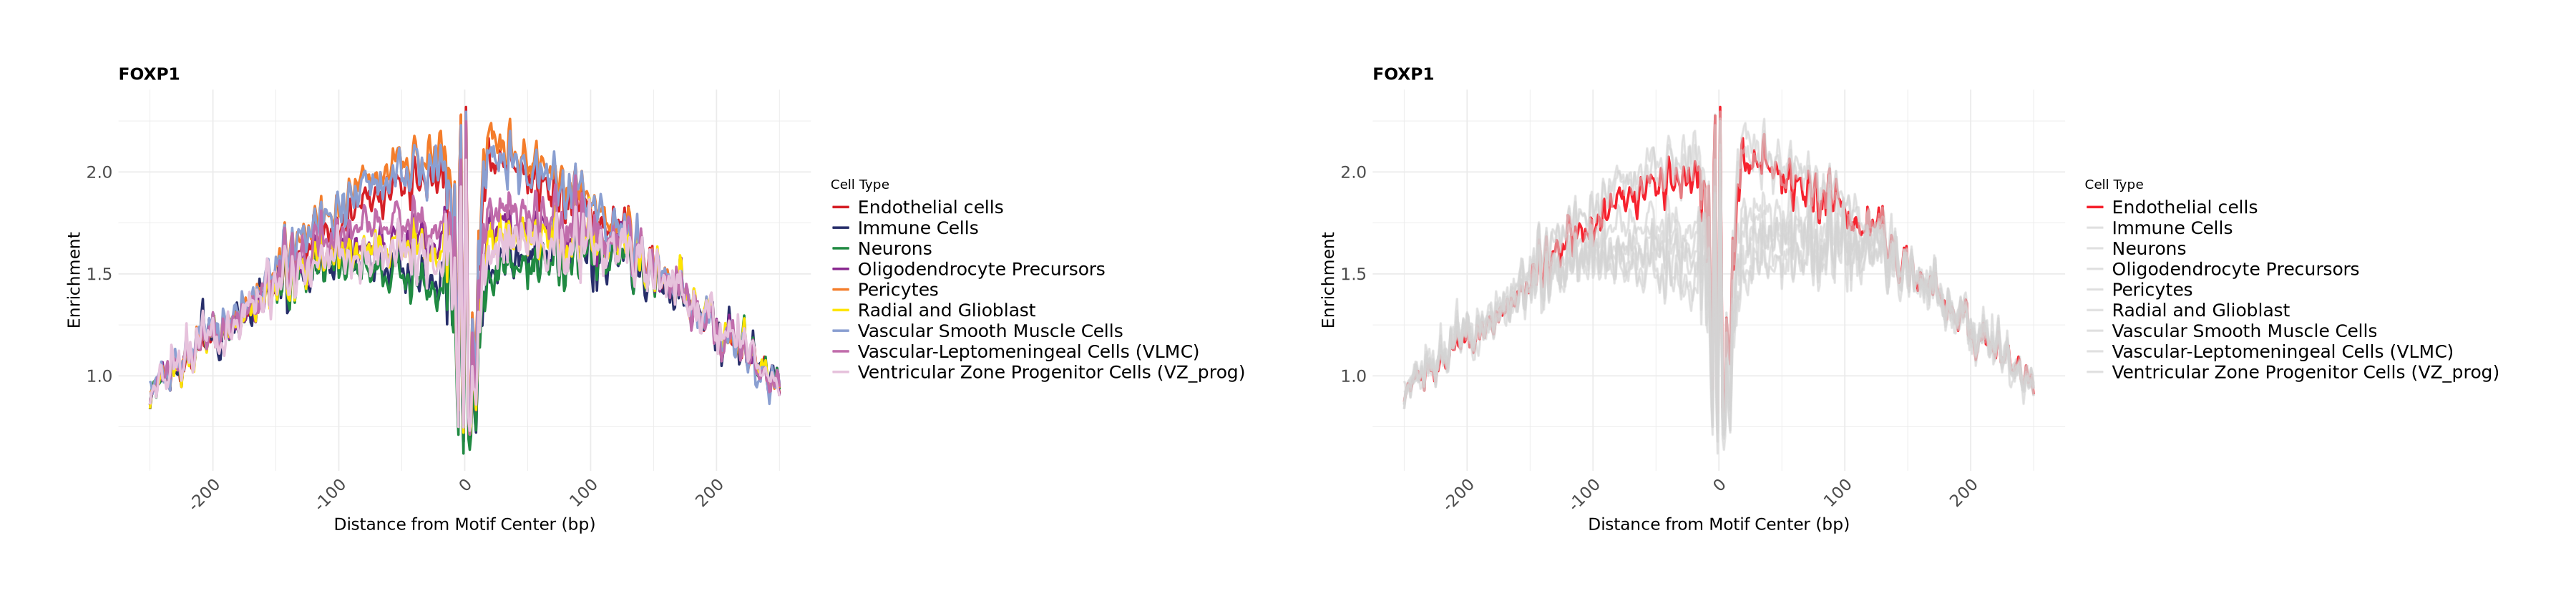

In [31]:
plot_multiple_TFs_w_highlights(tf_genes = 'FOXP1', # it takes multiple inputs.
                               peaks_gr = peaks_gr, 
                               fragments = subsetted_fragments, 
                               metadata = metadata, 
                               pwms_mat = my_human_pwms_v2, 
                               genes =  genes_info, 
                               colors_highlight =  highlight_EC_v2, 
                               set_theme = my_theme, 
                               set_margin = my_margin)

Motifs selected: RFX3

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


$RFX3


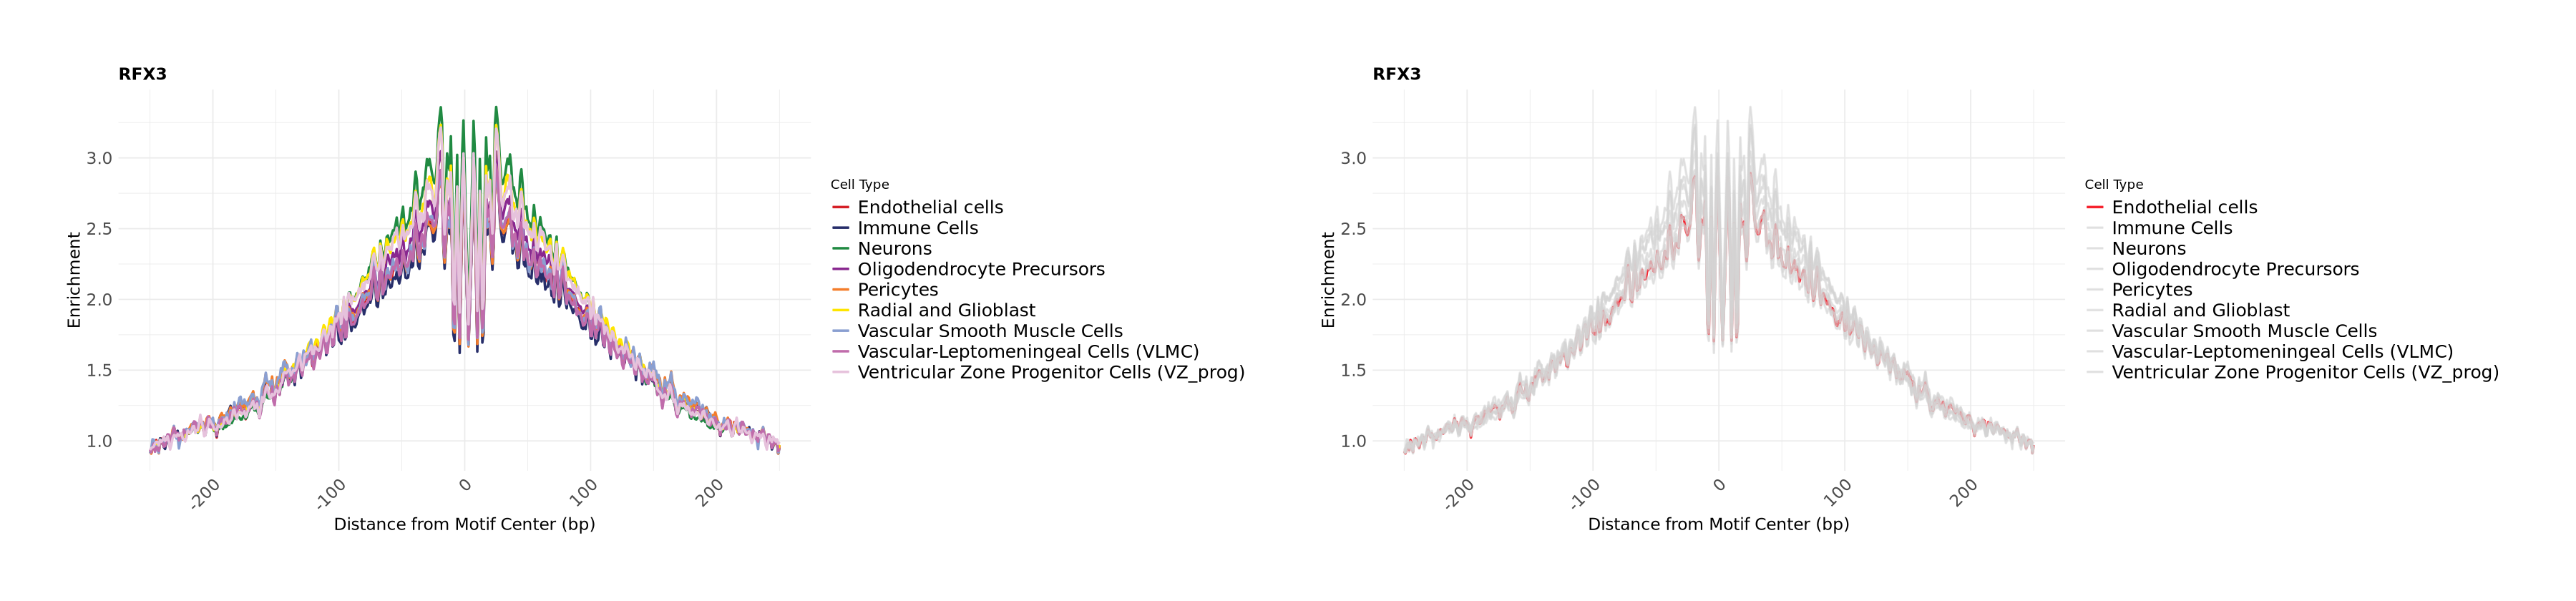

In [32]:
plot_multiple_TFs_w_highlights(tf_genes = 'RFX3', # it takes multiple inputs.
                               peaks_gr = peaks_gr, 
                               fragments = subsetted_fragments, 
                               metadata = metadata, 
                               pwms_mat = my_human_pwms_v2, 
                               genes =  genes_info, 
                               colors_highlight =  highlight_EC_v2, 
                               set_theme = my_theme, 
                               set_margin = my_margin)

Motifs selected: YBX1

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


$YBX1


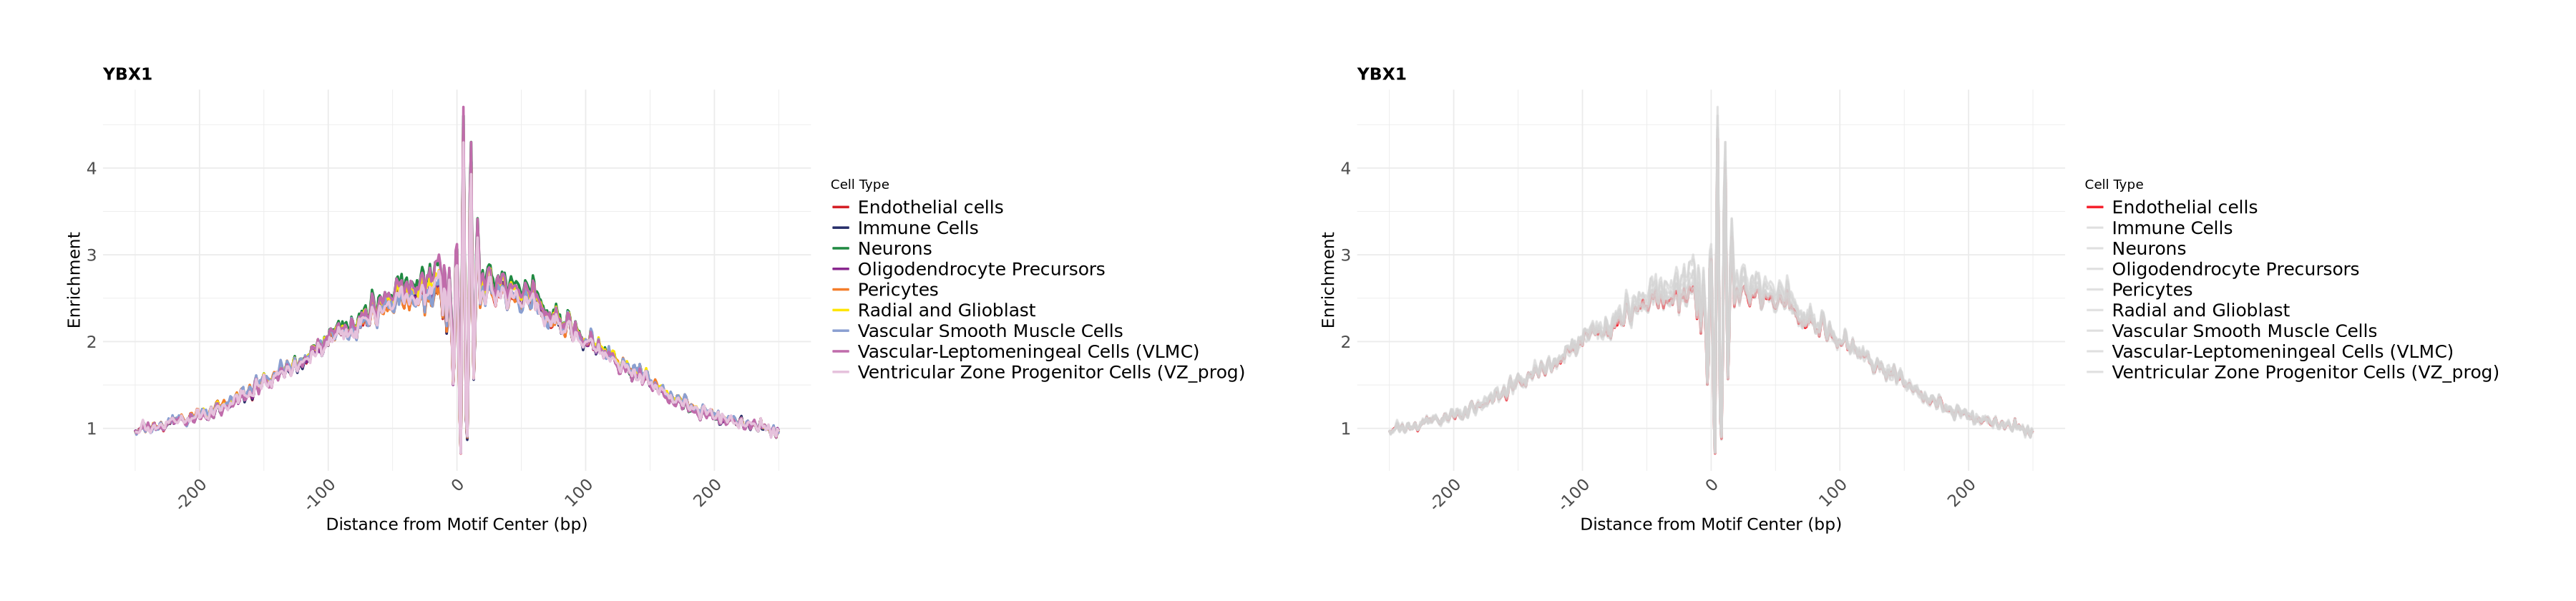

In [33]:
plot_multiple_TFs_w_highlights(tf_genes = 'YBX1', # it takes multiple inputs.
                               peaks_gr = peaks_gr, 
                               fragments = subsetted_fragments, 
                               metadata = metadata, 
                               pwms_mat = my_human_pwms_v2, 
                               genes =  genes_info, 
                               colors_highlight =  highlight_EC_v2, 
                               set_theme = my_theme, 
                               set_margin = my_margin)

Motifs selected: MECOM

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


$MECOM


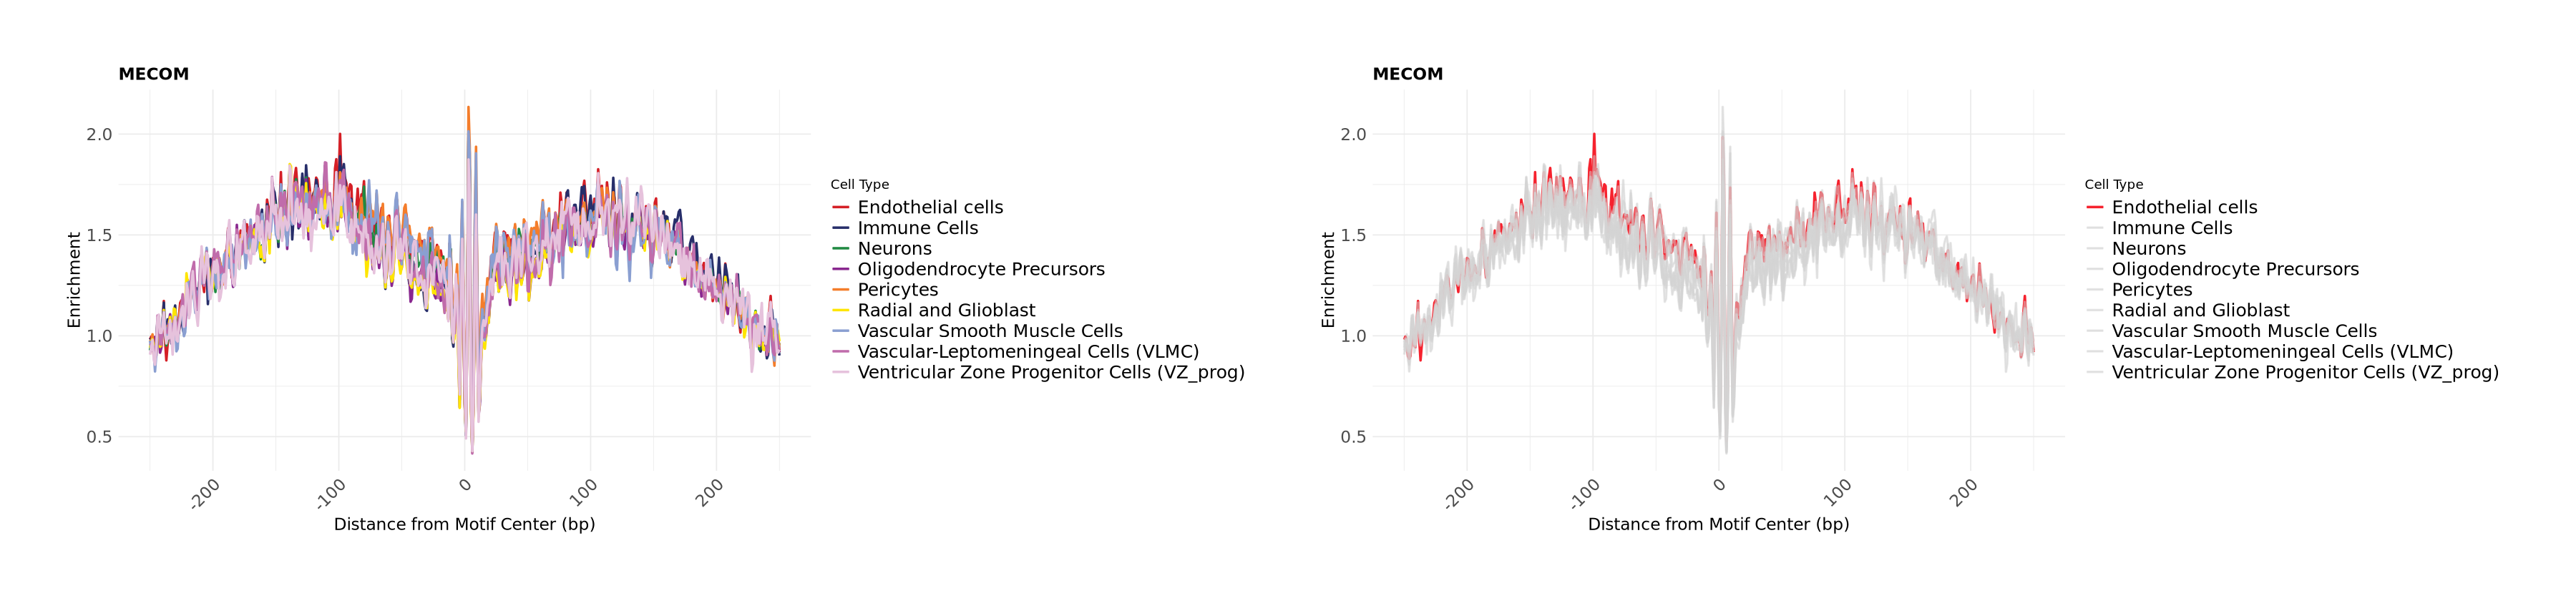

In [34]:
plot_multiple_TFs_w_highlights(tf_genes = 'MECOM', # it takes multiple inputs.
                               peaks_gr = peaks_gr, 
                               fragments = subsetted_fragments, 
                               metadata = metadata, 
                               pwms_mat = my_human_pwms_v2, 
                               genes =  genes_info, 
                               colors_highlight =  highlight_EC_v2, 
                               set_theme = my_theme, 
                               set_margin = my_margin)

Motifs selected: TEAD1

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


$TEAD1


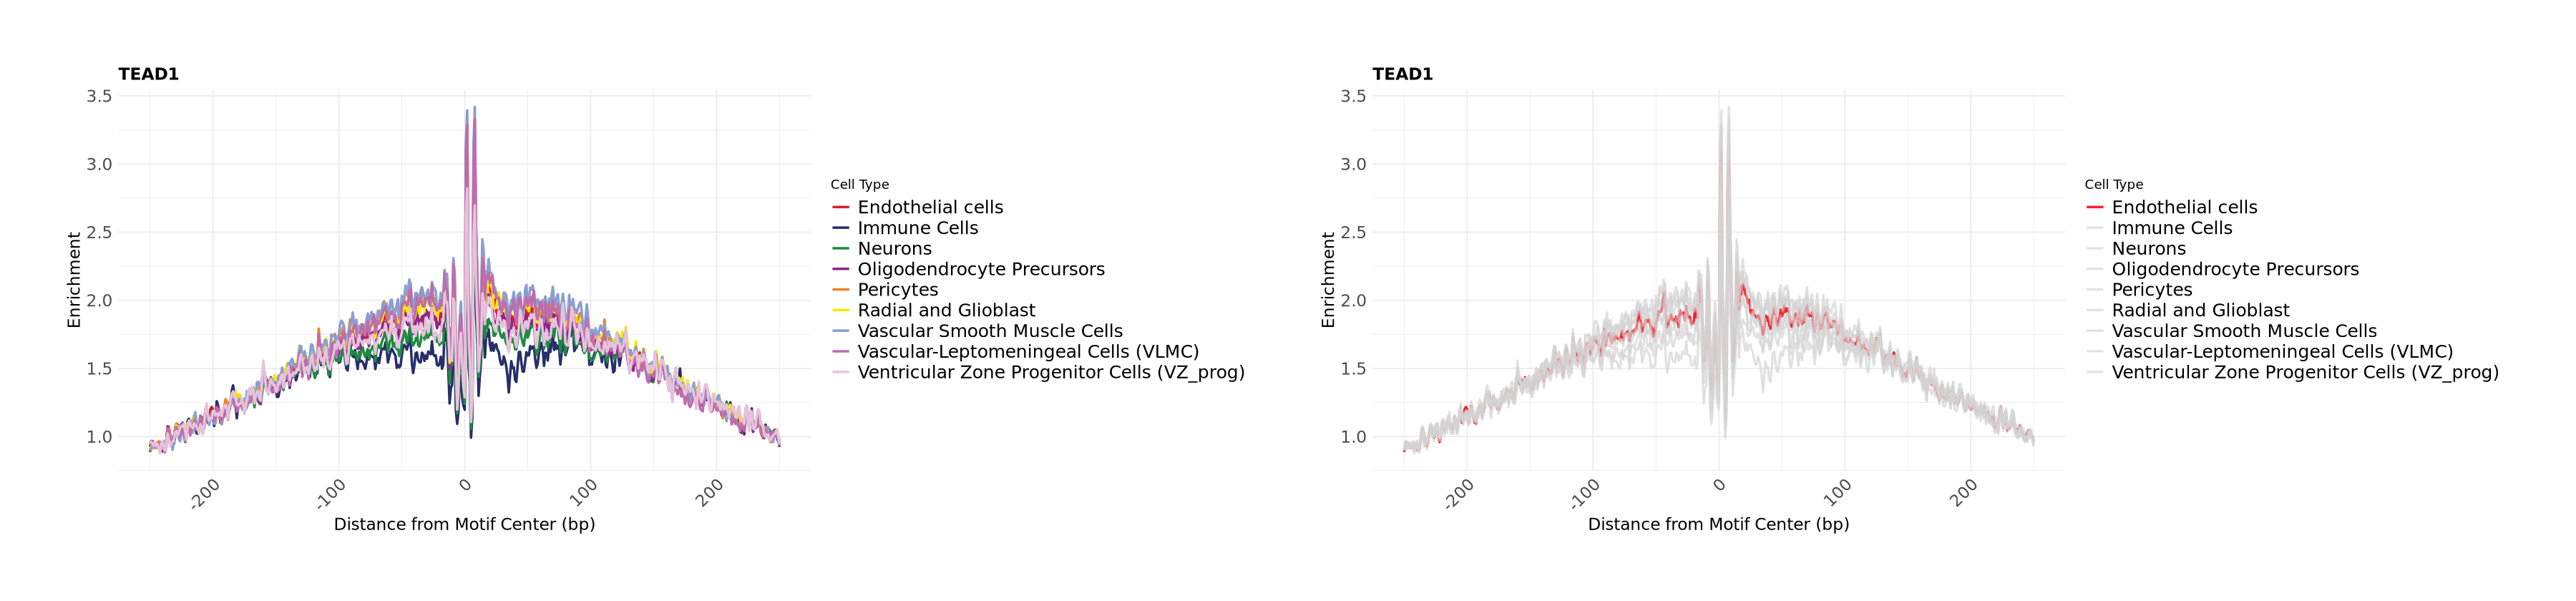

In [35]:
plot_multiple_TFs_w_highlights(tf_genes = 'TEAD1', # it takes multiple inputs.
                               peaks_gr = peaks_gr, 
                               fragments = subsetted_fragments, 
                               metadata = metadata, 
                               pwms_mat = my_human_pwms_v2, 
                               genes =  genes_info, 
                               colors_highlight =  highlight_EC_v2, 
                               set_theme = my_theme, 
                               set_margin = my_margin)

In [36]:
source(here::here('r_scripts', 'plot_genome_coverage_functions_using_BPCells.r'))

In [37]:
read_counts <- readRDS(here::here('r_objects', 'atac_read_counts_by_BPCells.RDS'))

In [38]:
transcripts_info <- read_gencode_transcripts("./references", release="42")
head(transcripts_info)

chr,source,feature,start,end,score,strand,frame,gene_id,gene_type,gene_name,transcript_id,MANE_Select
<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
chr1,HAVANA,transcript,65418,71585,.,+,.,ENSG00000186092.7,protein_coding,OR4F5,ENST00000641515.2,TRUE
chr1,HAVANA,exon,65418,65433,.,+,.,ENSG00000186092.7,protein_coding,OR4F5,ENST00000641515.2,TRUE
chr1,HAVANA,exon,65519,65573,.,+,.,ENSG00000186092.7,protein_coding,OR4F5,ENST00000641515.2,TRUE
chr1,HAVANA,exon,69036,71585,.,+,.,ENSG00000186092.7,protein_coding,OR4F5,ENST00000641515.2,TRUE
chr1,HAVANA,transcript,450739,451678,.,-,.,ENSG00000284733.2,protein_coding,OR4F29,ENST00000426406.4,TRUE
chr1,HAVANA,exon,450739,451678,.,-,.,ENSG00000284733.2,protein_coding,OR4F29,ENST00000426406.4,TRUE


In [39]:
mat_rna_norm_pseudobulk <- readRDS(file = here::here('r_objects', 'mat_rna_norm_pseudobulk.RDS'))

In [40]:
my_important_TFs_gene_body_accessibilites <- vector(mode = 'list', length = length(important_TFs))

for (each_TF in important_TFs) {

my_important_TFs_gene_body_accessibilites[[each_TF]] <- plot_gene_coverage_w_BULK_expression(total_reads_per_cell = read_counts,
                                       bulked_rna_data = mat_rna_norm_pseudobulk,
                                       bins_value = 500, 
                                       extend.bp = 1e5 , 
                                       genes_info = genes_info,
                                       transcripts_info = transcripts_info,
                                       fragments = subsetted_fragments,  
                                       gene = each_TF, 
                                       cell_types = metadata$main_cell_types)
    }

NULL
NULL
NULL
NULL
NULL
NULL
NULL


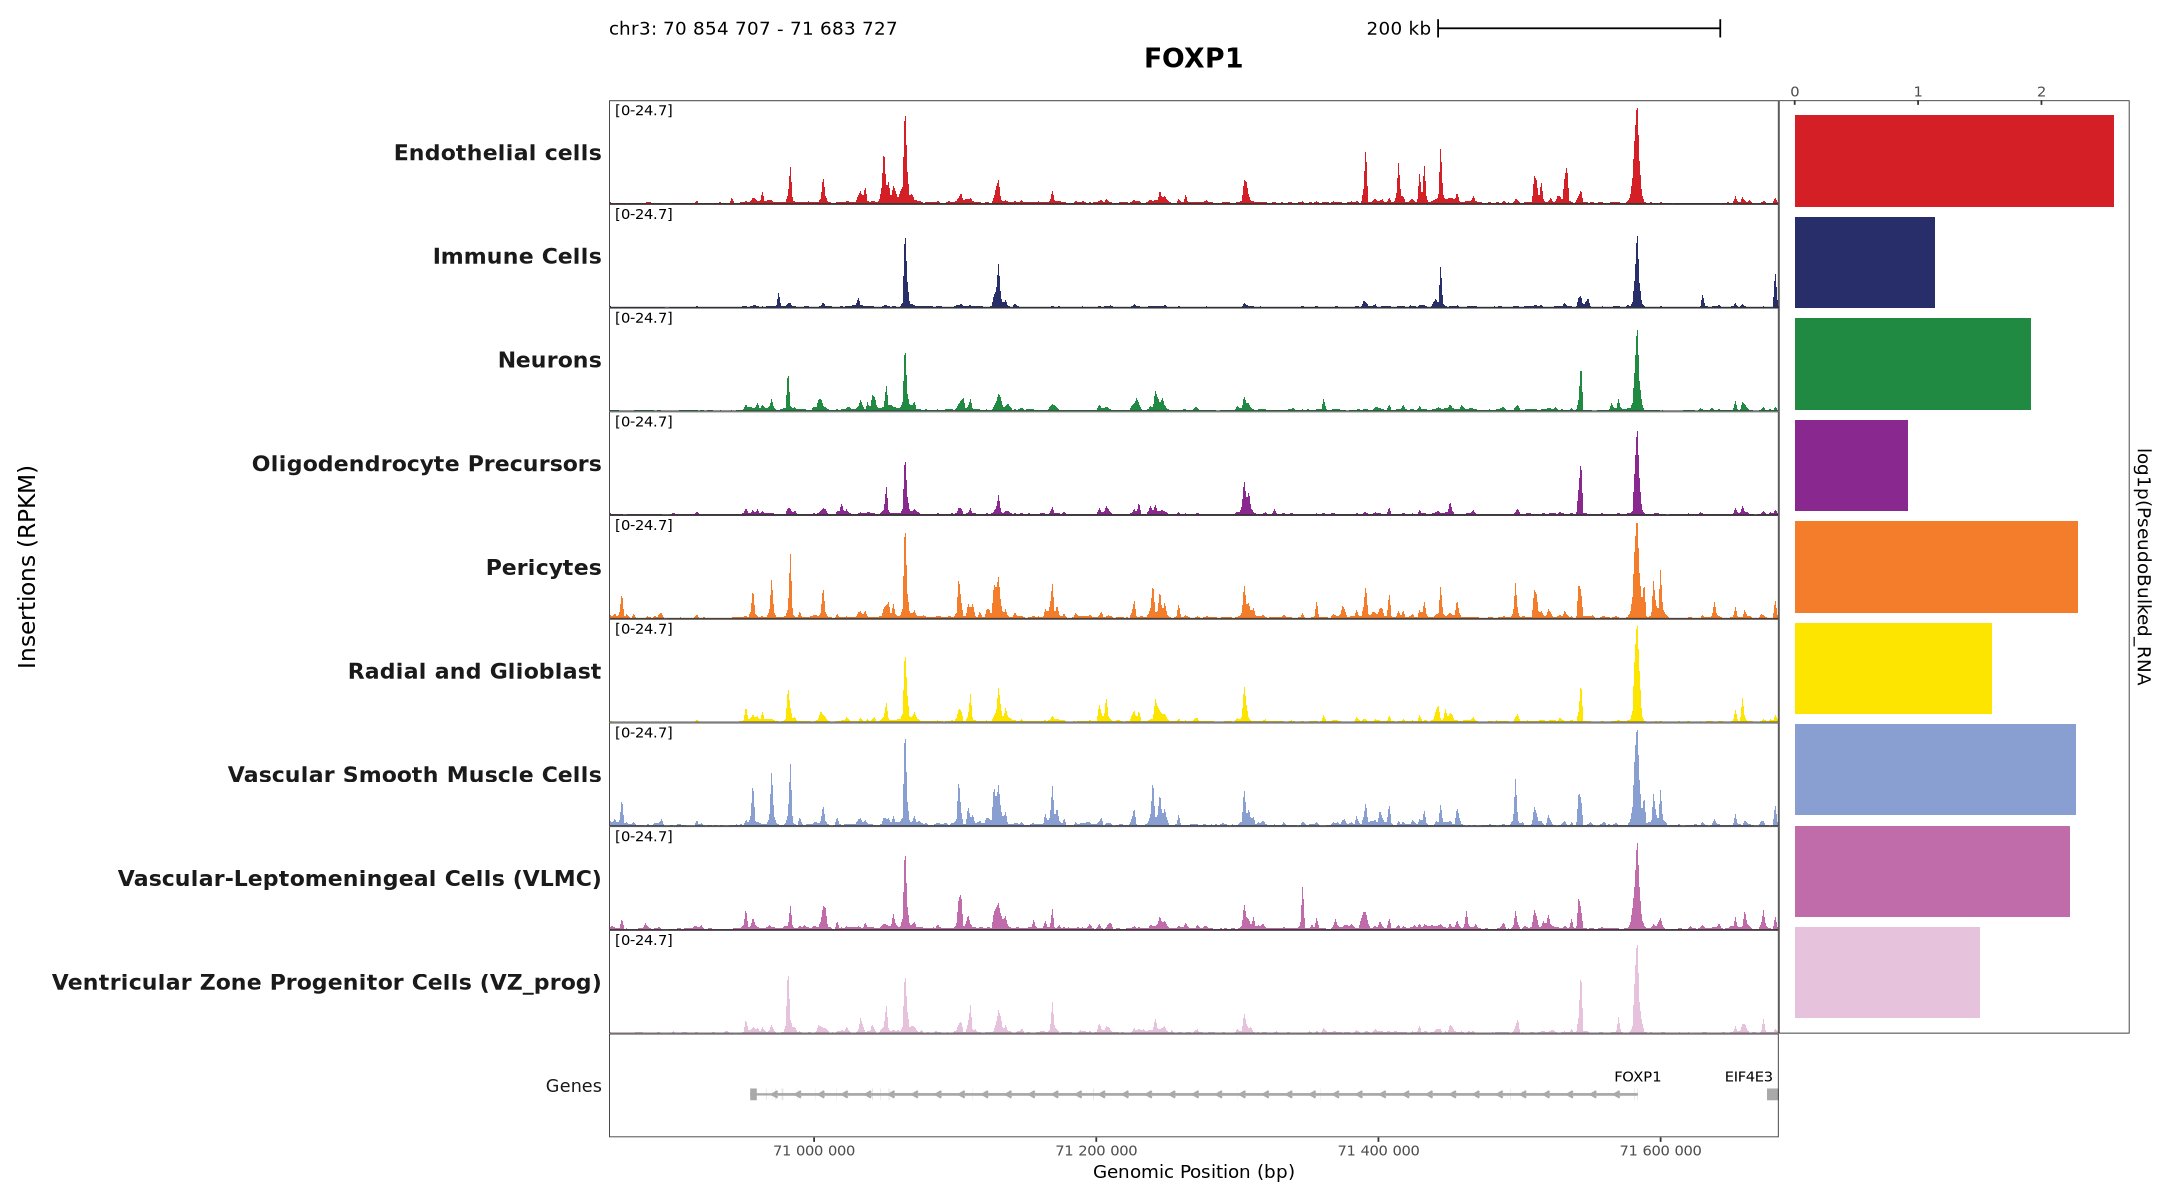

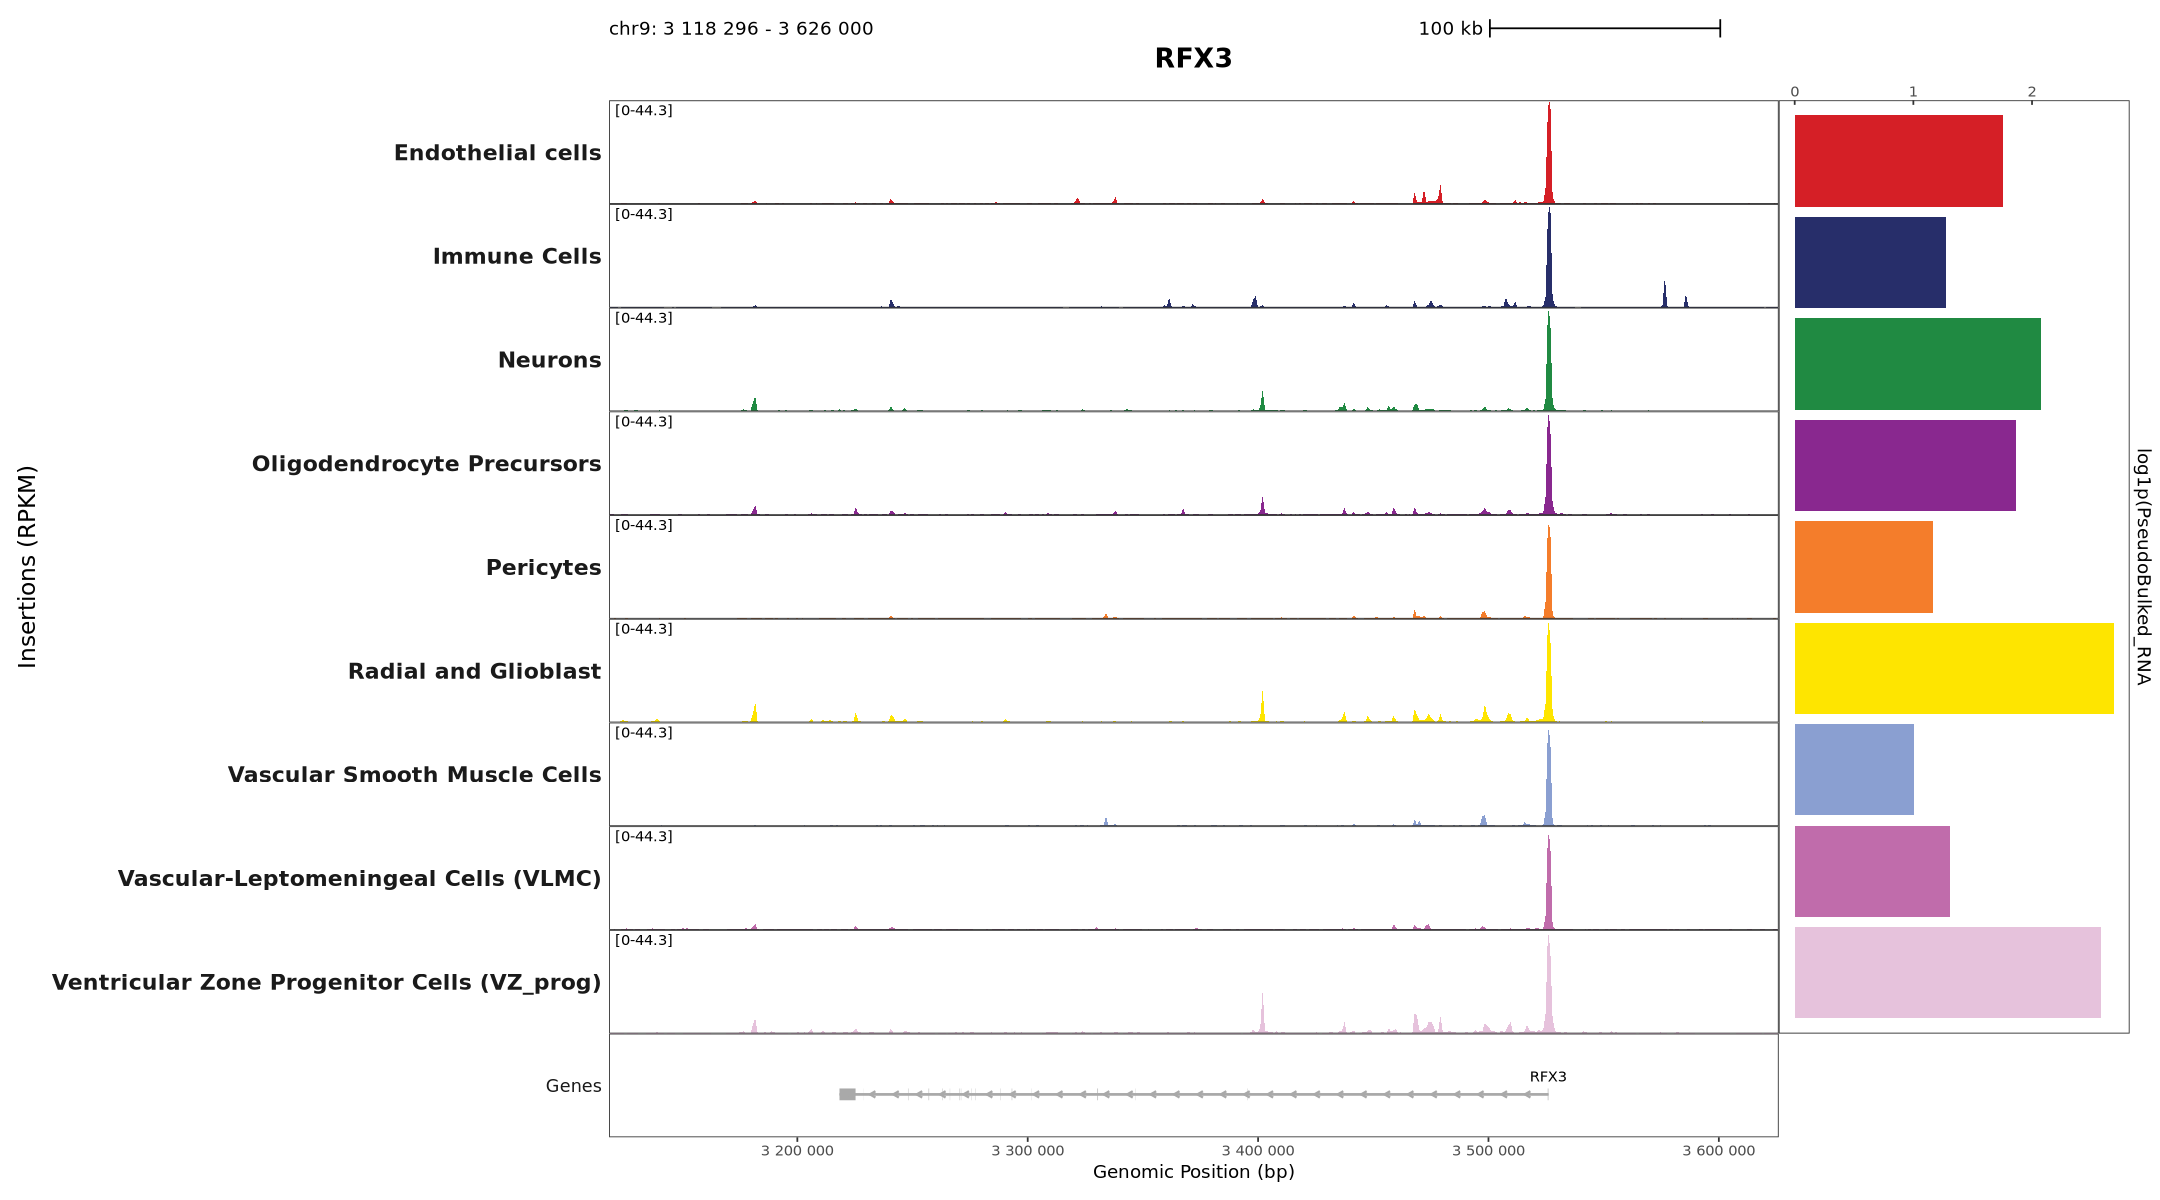

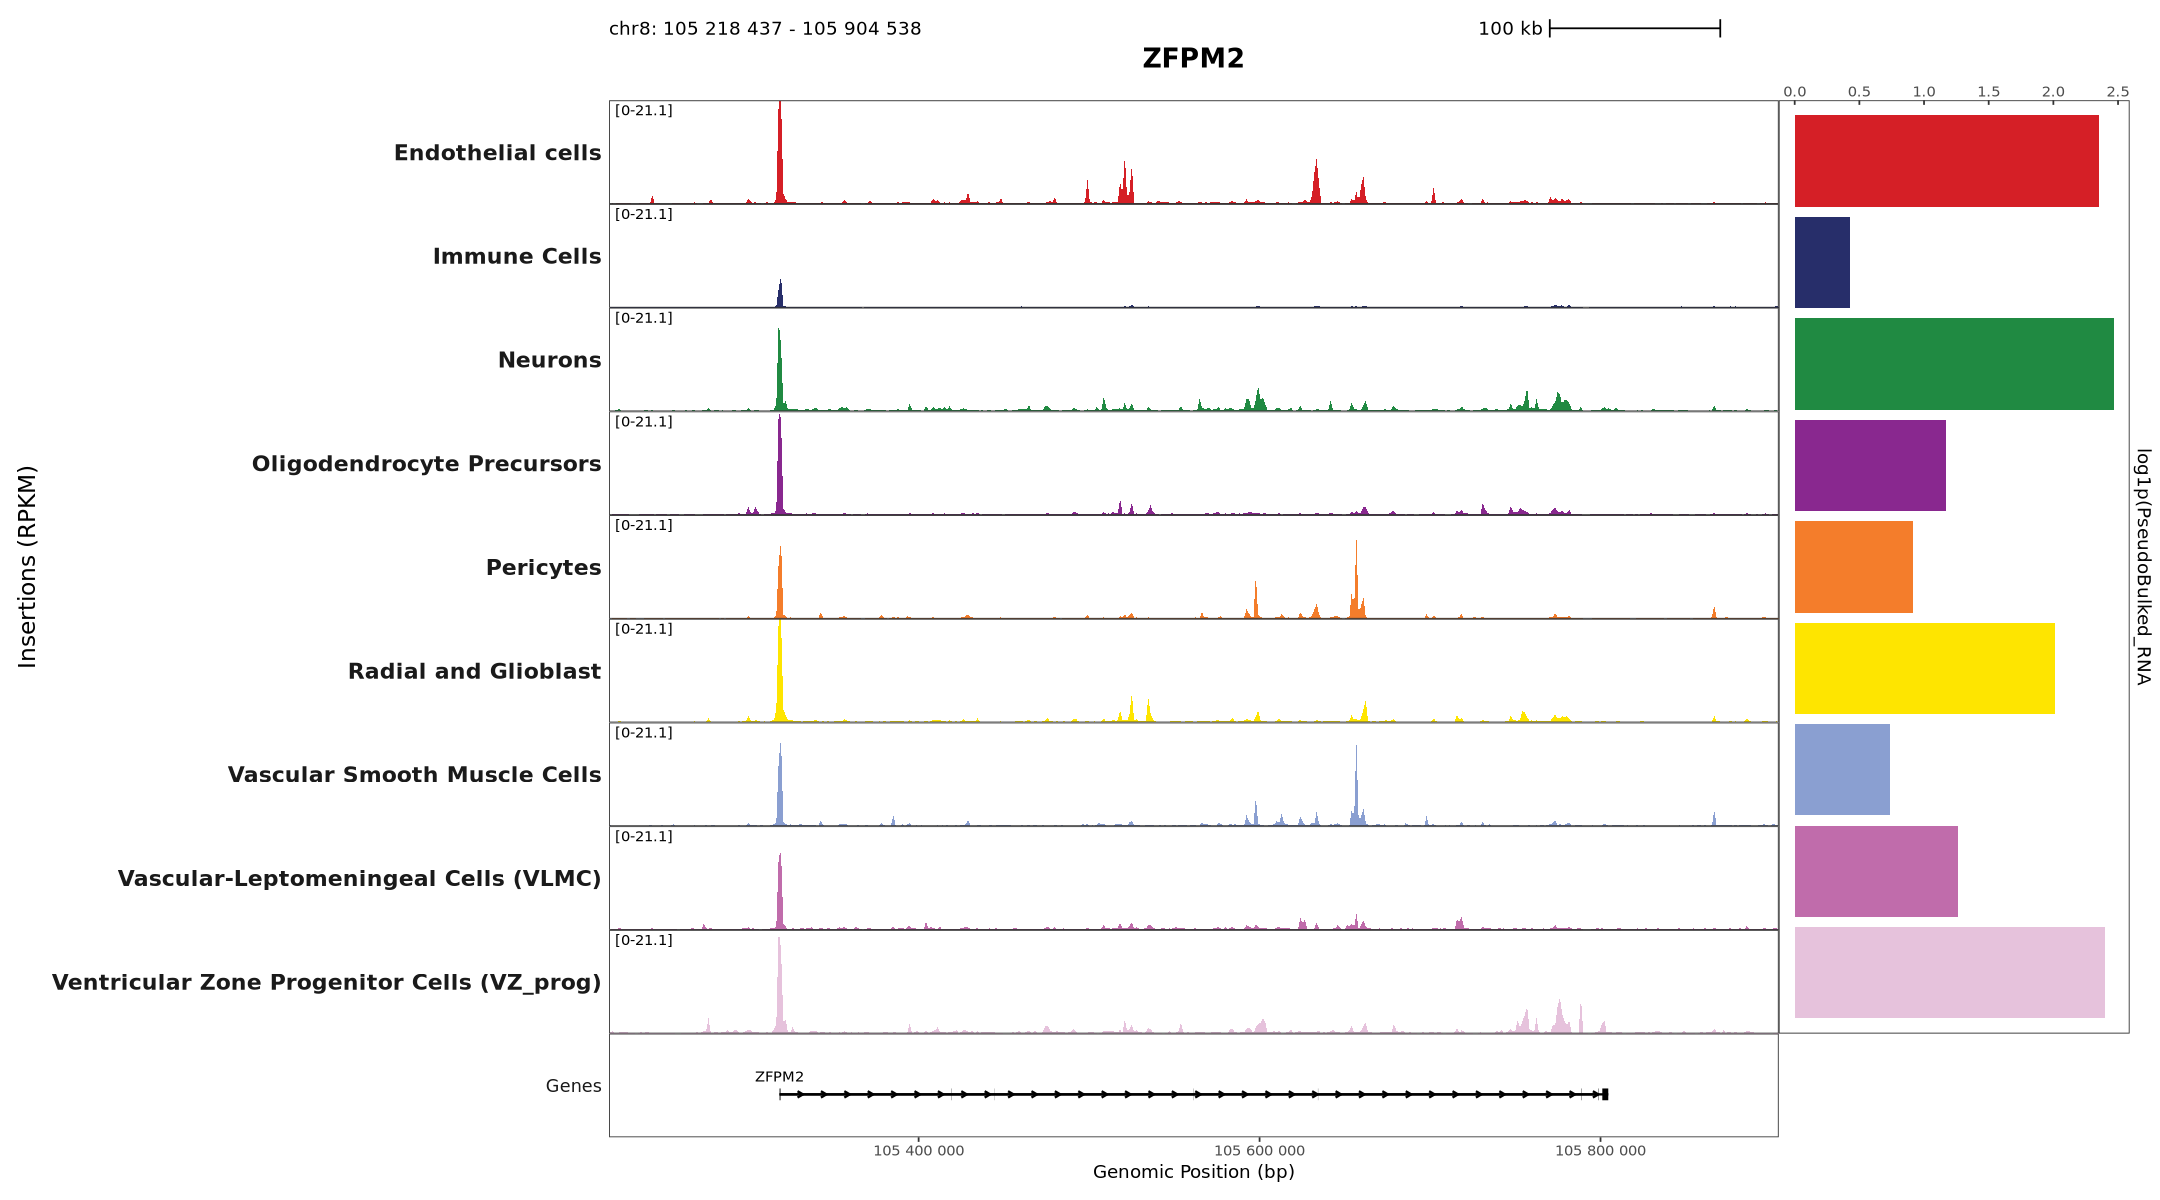

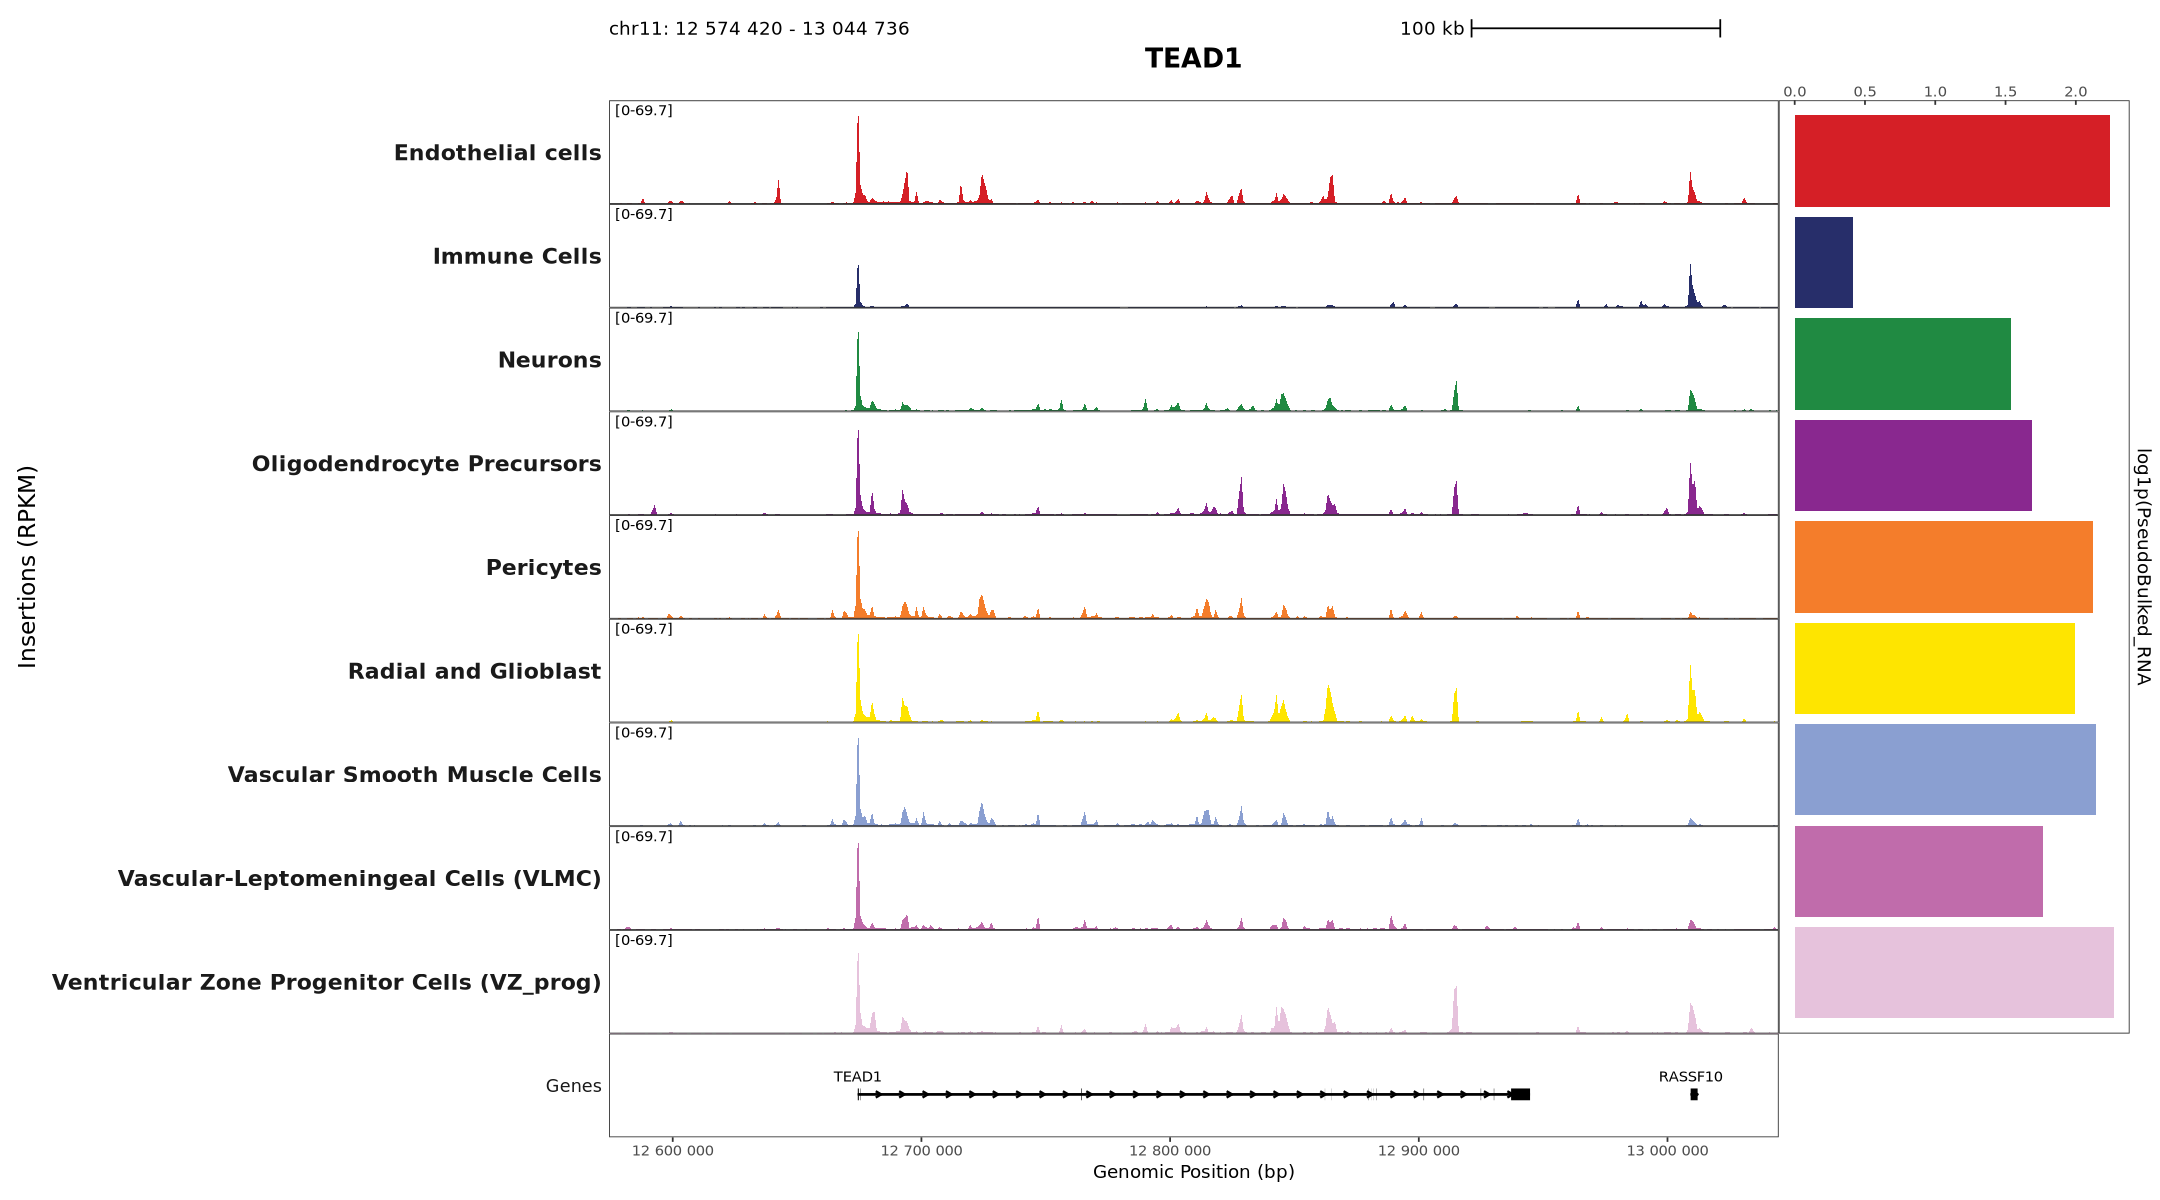

Warning message:
"ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


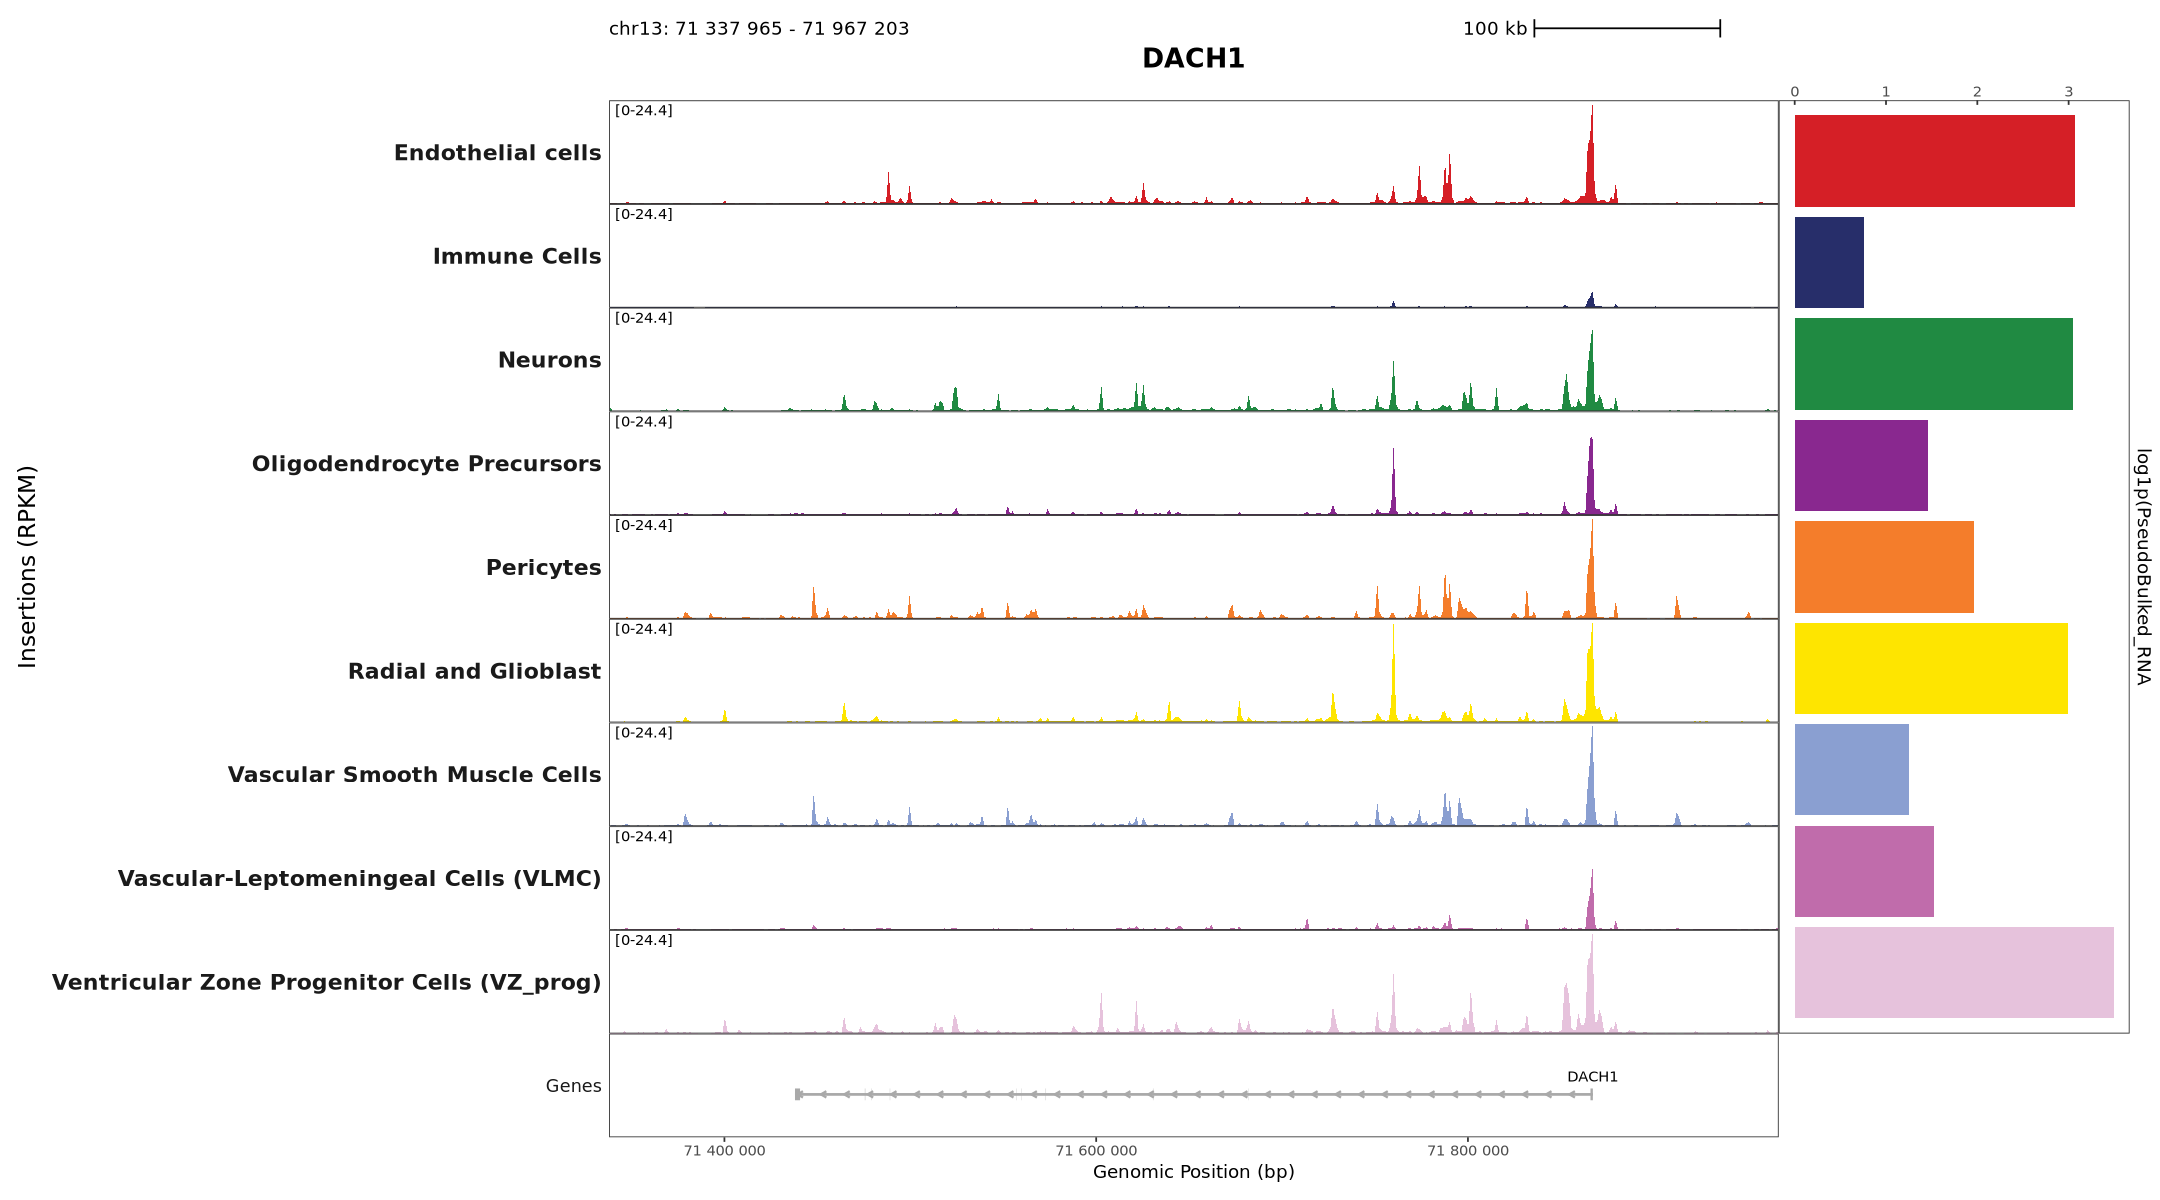

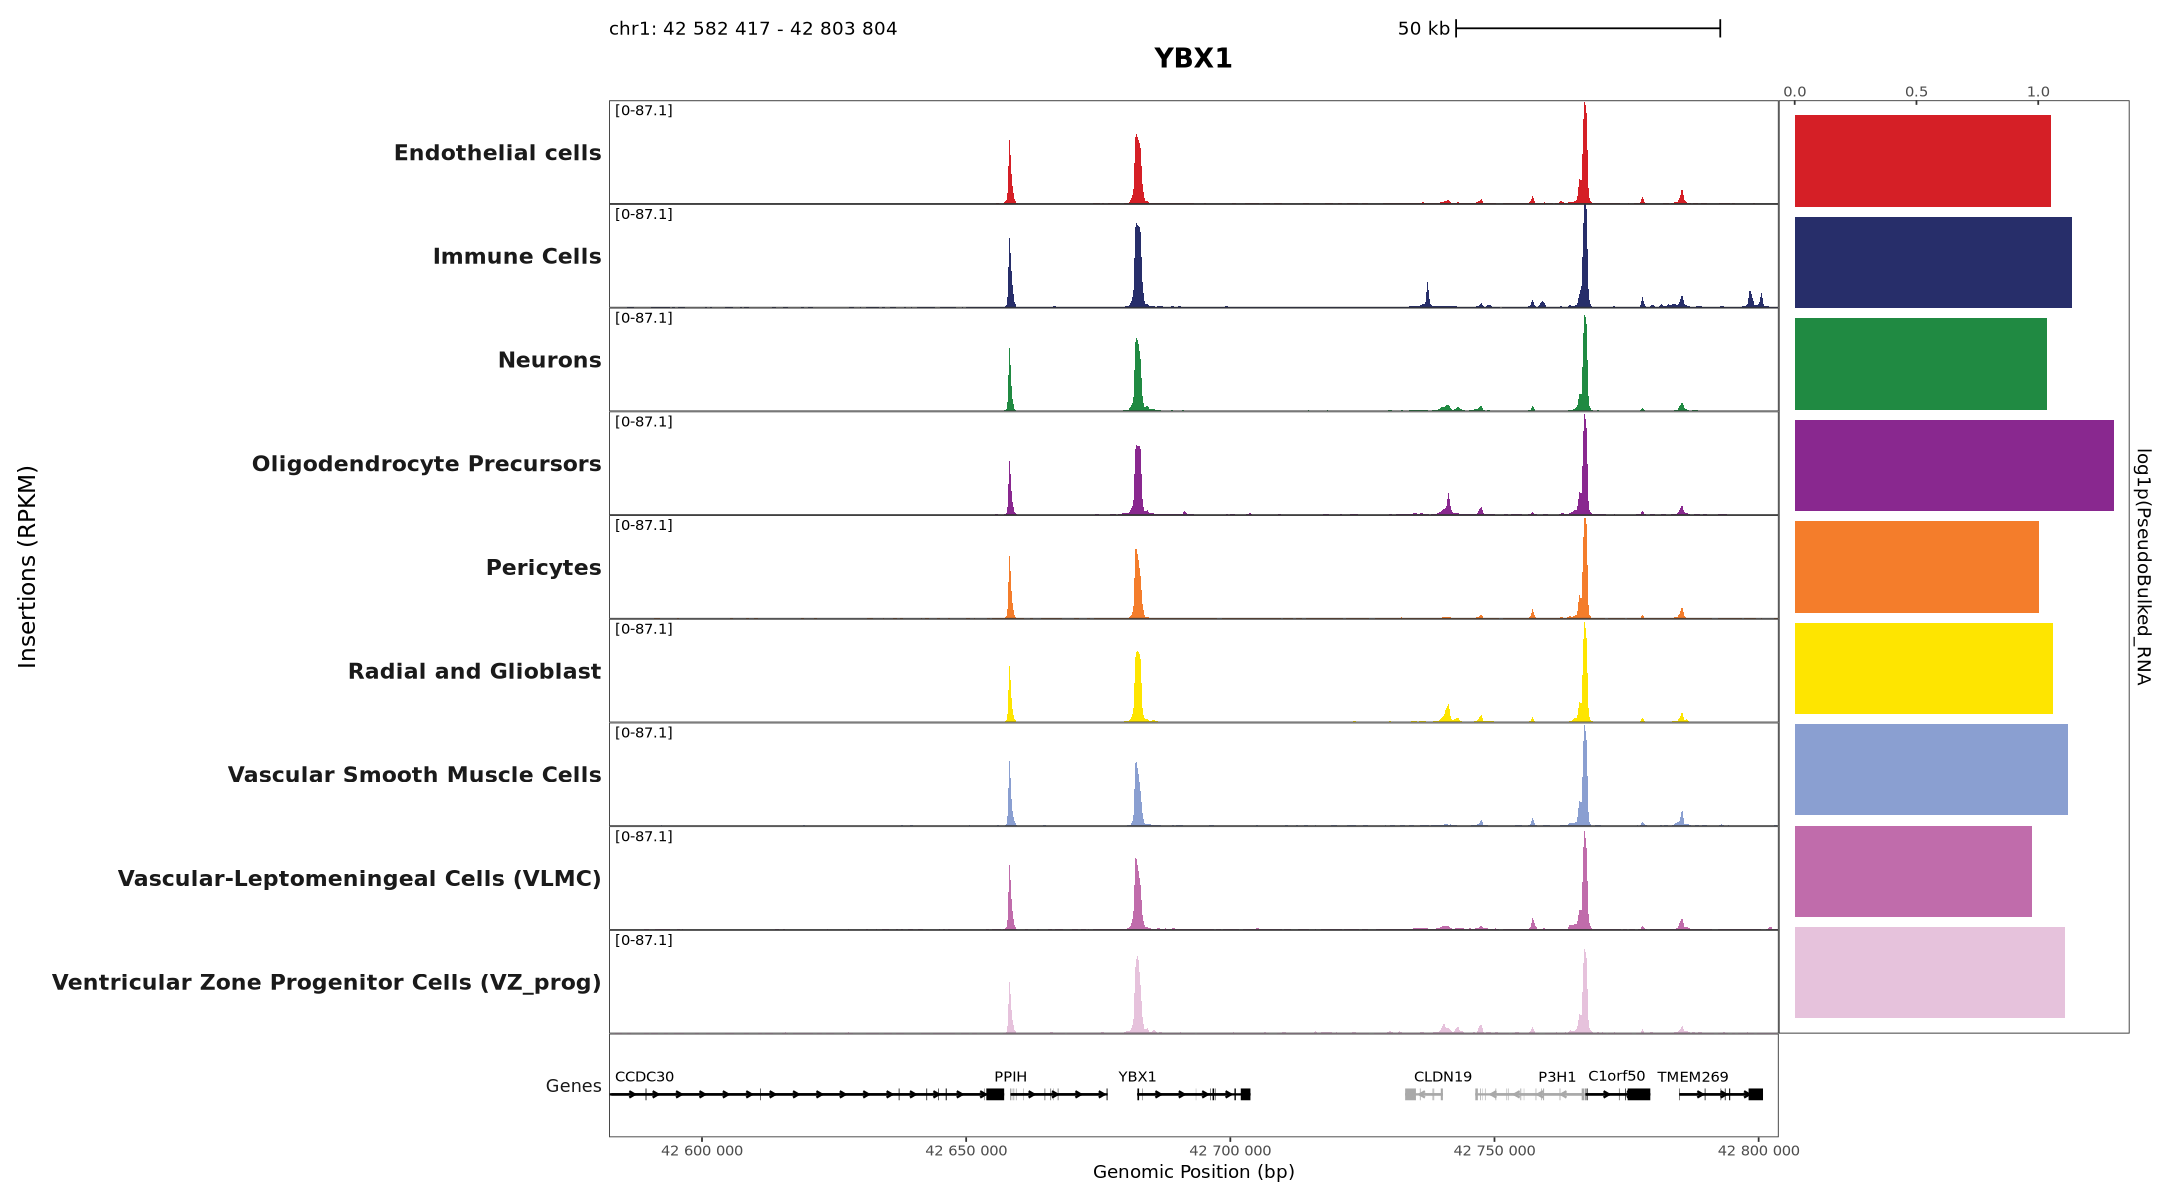

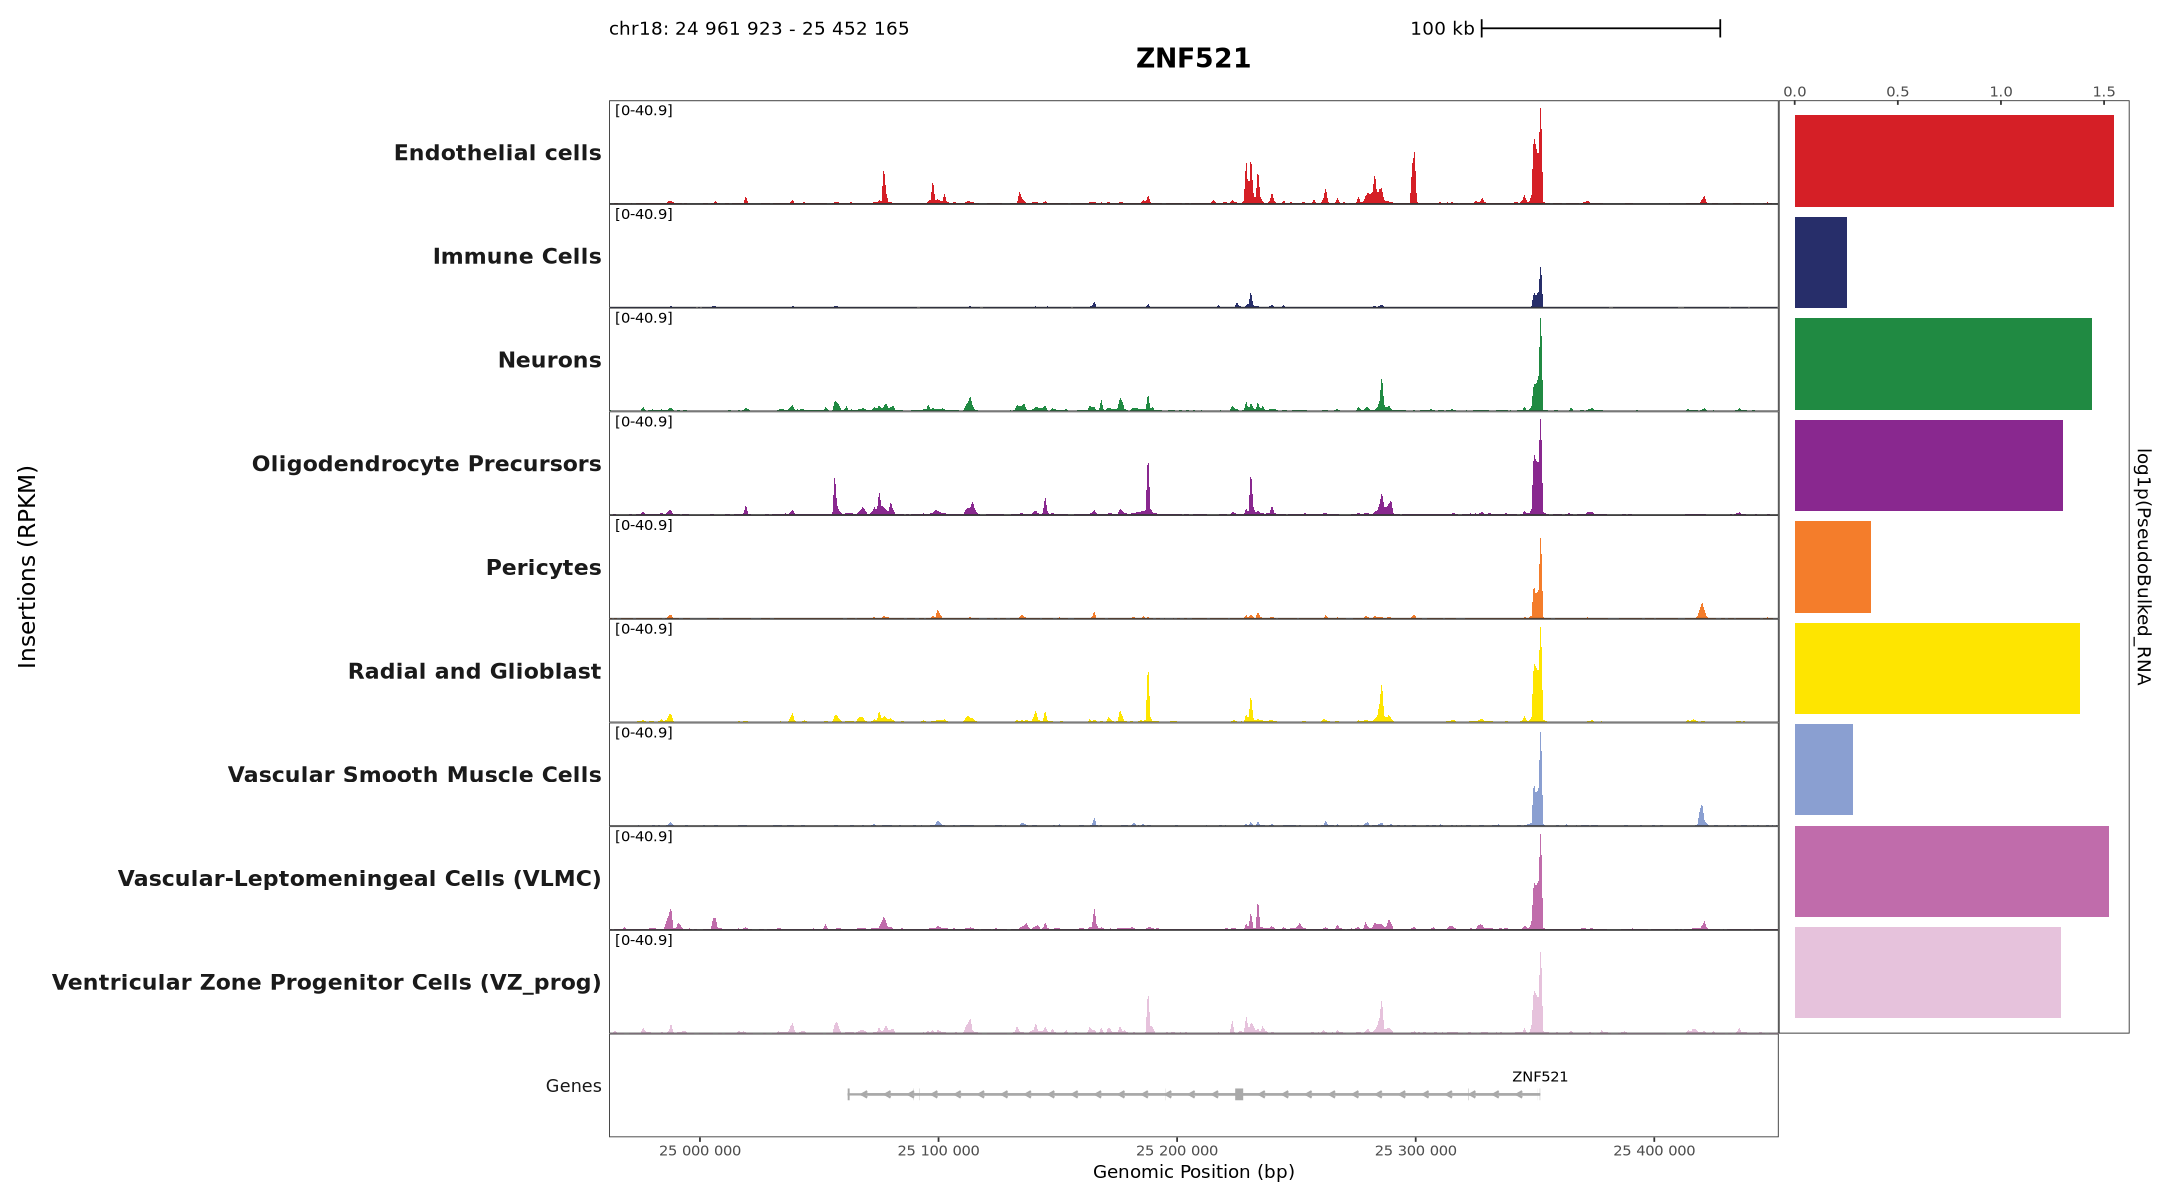

In [41]:
# view plots:

options(repr.plot.width = 18, repr.plot.height = 10)

for(i in seq_along(my_important_TFs_gene_body_accessibilites)){

    print(my_important_TFs_gene_body_accessibilites[[i]])
    
    }

I also updated the plot_TF_footprints functions in the 'r_scripts' folder.

In [42]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-unknown-linux-gnu
Running under: Red Hat Enterprise Linux 9.4 (Plow)

Matrix products: default
BLAS/LAPACK: /gnu/store/mj1kw87qd3m1q7r4844adkn5hifx8k6a-openblas-0.3.20/lib/libopenblasp-r0.3.20.so;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=C          LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C.UTF-8
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] BSgenome.Hsapiens.UCSC.hg38_1.4.5 BSgenome_1.74.0                  
 [3] rtracklayer_1.66.0                BiocIO_1.16.0                    
 [5] Biostrings_2.74.0                 XVector_0.46.0                   
 [7] GenomicRanges_1.58.0              GenomeInfoDb_